In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
data_1 = pd.read_csv("/content/drive/MyDrive/Grad project/dataset_v2_master_training.csv", low_memory=False)
data_1.head()

,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,flow_duration,total_packets,total_bytes,avg_packet_size,...,arp_reply_rate,arp_request_rate,arp_reply_request_ratio,arp_gratuitous_count,arp_unsolicited_count,mac_ip_binding_changes,ip_mac_binding_changes,label,attack_type,snort_sid
0,2026-06-20T21:29:32.987864,10.0.0.3,10.0.0.4,0,0,ARP,0.0049,4,168,42.0,...,0.0000,4041.7287,0.0000,0,0,0,0,0,normal,none
1,2026-06-20T21:29:32.989954,10.0.0.4,10.0.0.3,0,0,ARP,0.0025,2,84,42.0,...,810.8069,6486.4551,0.1176,0,0,0,0,0,normal,none
2,2026-06-20T21:29:32.992616,10.0.0.3,10.0.0.4,0,0,ICMP,0.0961,3,294,98.0,...,0.0000,0.0000,0.0000,0,0,0,0,0,normal,none
3,2026-06-20T21:29:32.995119,10.0.0.4,10.0.0.3,0,0,ICMP,0.0934,2,196,98.0,...,0.0000,0.0000,0.0000,0,0,0,0,0,normal,none
4,2026-06-20T21:29:33.015020,10.0.0.3,10.0.0.5,0,0,ARP,0.0069,4,168,42.0,...,0.0000,2901.2271,0.0000,0,0,0,0,0,normal,none


In [ ]:
feature_dict = data_1.columns.tolist()
feature_dict

['timestamp',
 'src_ip',
 'dst_ip',
 'src_port',
 'dst_port',
 'protocol',
 'flow_duration',
 'total_packets',
 'total_bytes',
 'avg_packet_size',
 'min_packet_size',
 'max_packet_size',
 'packets_per_second',
 'bytes_per_second',
 'syn_count',
 'ack_count',
 'fin_count',
 'rst_count',
 'psh_count',
 'unique_src_ports',
 'unique_dst_ports',
 'inter_arrival_mean',
 'inter_arrival_std',
 'inter_arrival_cv',
 'inter_arrival_min',
 'inter_arrival_max',
 'burst_count',
 'burst_duration_avg',
 'fwd_packet_count',
 'bwd_packet_count',
 'fwd_bwd_packet_ratio',
 'fwd_bwd_bytes_ratio',
 'fwd_avg_packet_size',
 'bwd_avg_packet_size',
 'reply_rate',
 'syn_ack_ratio',
 'completed_sessions',
 'incomplete_ratio',
 'avg_session_duration',
 'payload_size_entropy',
 'src_port_entropy',
 'icmp_type_entropy',
 'pkt_size_std',
 'pkt_size_variance',
 'small_pkt_ratio',
 'large_pkt_ratio',
 'top_dst_port',
 'top_dst_port_ratio',
 'dst_port_std',
 'well_known_port_ratio',
 'ephemeral_port_ratio',
 'sequential

In [ ]:
features_to_drop = [
  'timestamp',
  'src_ip',
  'dst_ip',
  'src_port',
  'dst_port',
  'top_dst_port',
  'snort_sid',
  'active_snort_alerts',
  'distinct_alert_types',
]
data_1 = data_1.drop(columns=features_to_drop, axis=1, errors='ignore')
feature_dict = data_1.columns.tolist()
feature_dict

['protocol',
 'flow_duration',
 'total_packets',
 'total_bytes',
 'avg_packet_size',
 'min_packet_size',
 'max_packet_size',
 'packets_per_second',
 'bytes_per_second',
 'syn_count',
 'ack_count',
 'fin_count',
 'rst_count',
 'psh_count',
 'unique_src_ports',
 'unique_dst_ports',
 'inter_arrival_mean',
 'inter_arrival_std',
 'inter_arrival_cv',
 'inter_arrival_min',
 'inter_arrival_max',
 'burst_count',
 'burst_duration_avg',
 'fwd_packet_count',
 'bwd_packet_count',
 'fwd_bwd_packet_ratio',
 'fwd_bwd_bytes_ratio',
 'fwd_avg_packet_size',
 'bwd_avg_packet_size',
 'reply_rate',
 'syn_ack_ratio',
 'completed_sessions',
 'incomplete_ratio',
 'avg_session_duration',
 'payload_size_entropy',
 'src_port_entropy',
 'icmp_type_entropy',
 'pkt_size_std',
 'pkt_size_variance',
 'small_pkt_ratio',
 'large_pkt_ratio',
 'top_dst_port_ratio',
 'dst_port_std',
 'well_known_port_ratio',
 'ephemeral_port_ratio',
 'sequential_port_score',
 'is_broadcast_dst',
 'flows_per_window',
 'device_total_flows',


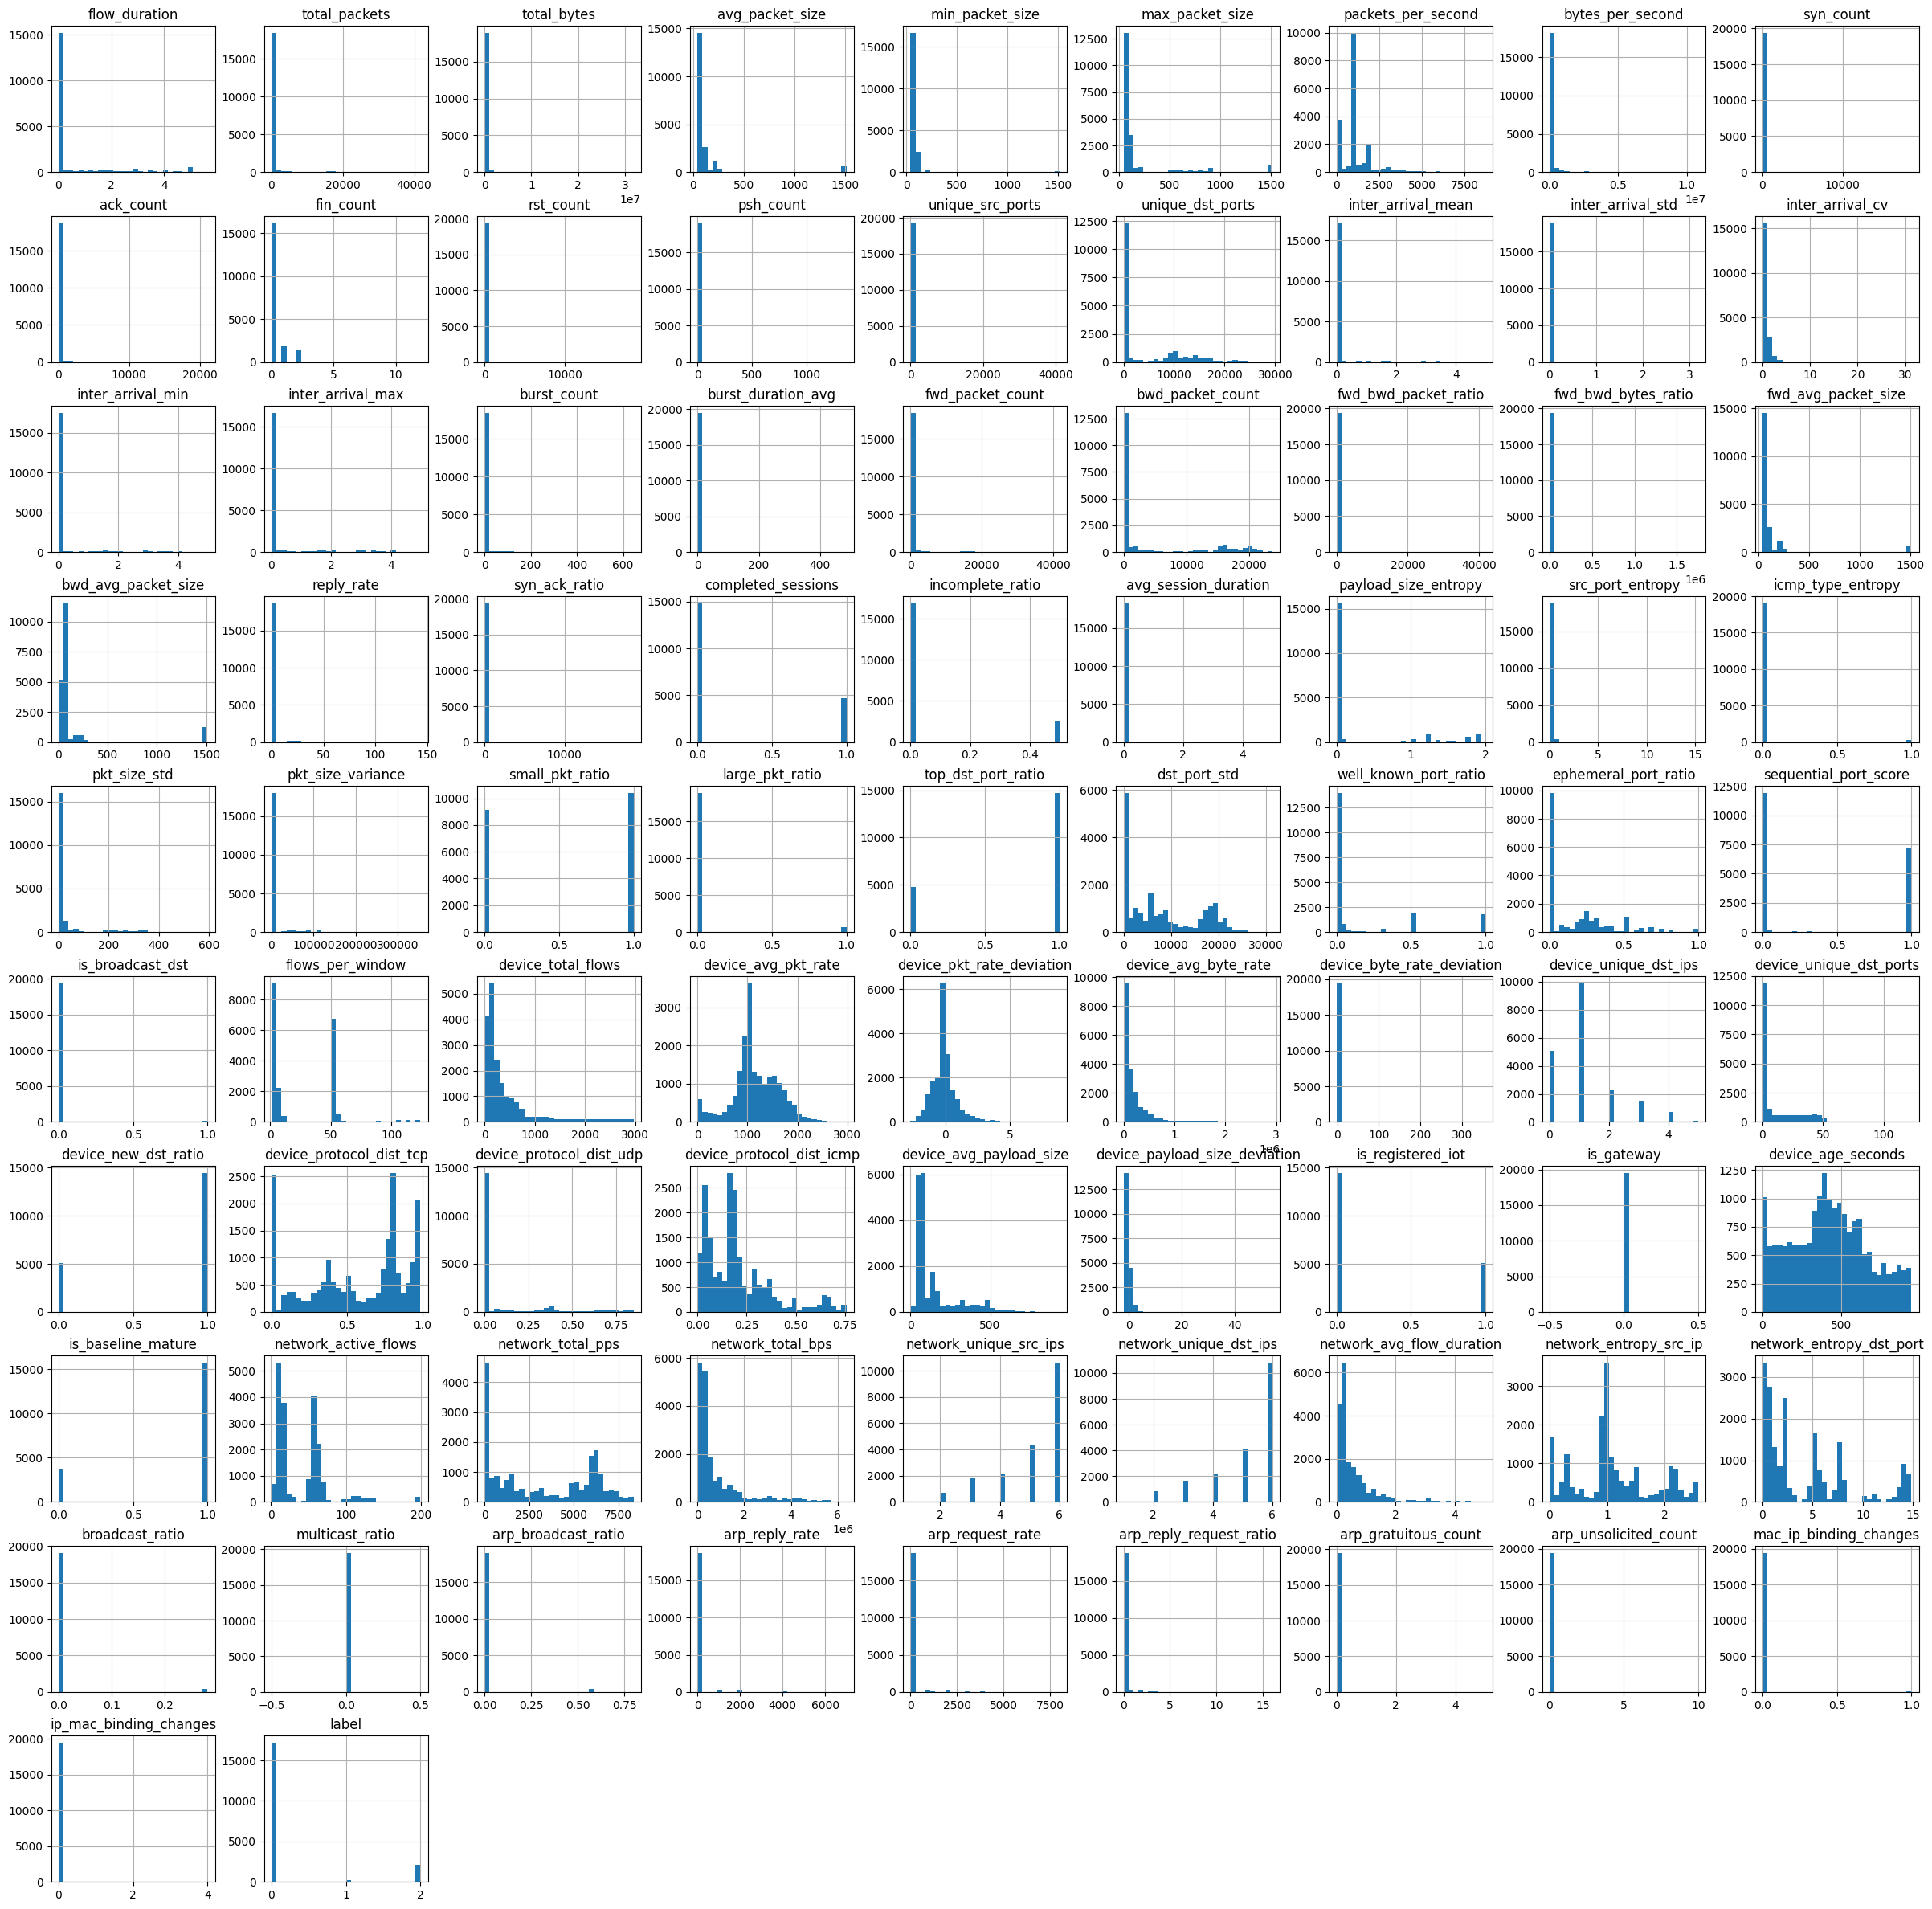

In [ ]:
data_1.hist(figsize=(30, 30), bins=30)
plt.show()

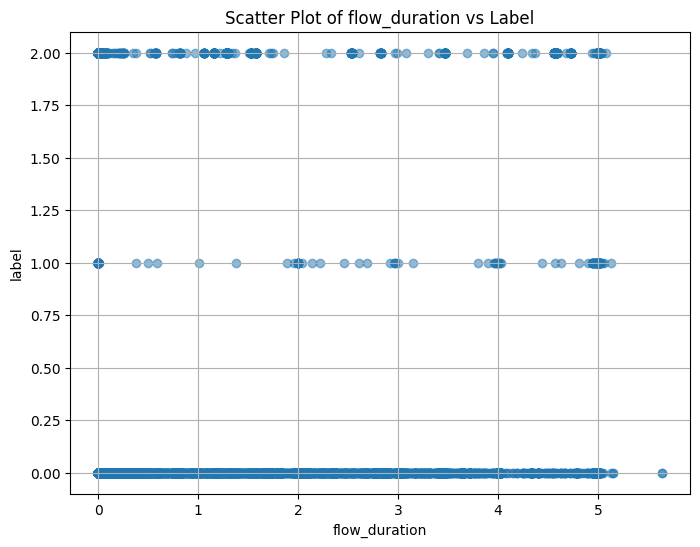

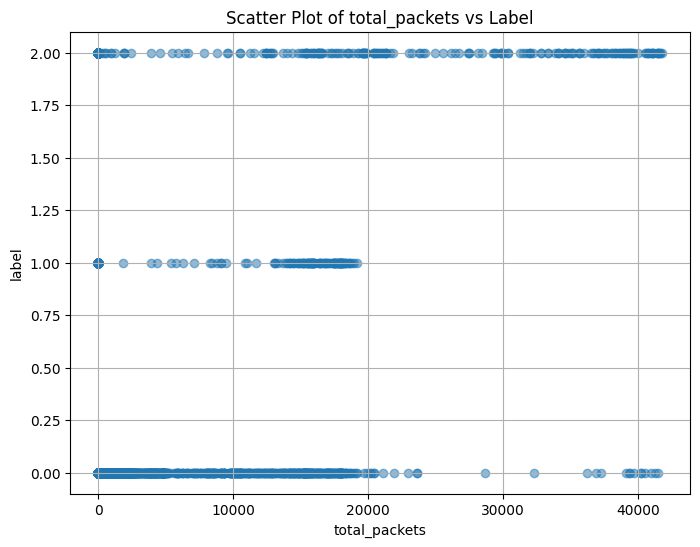

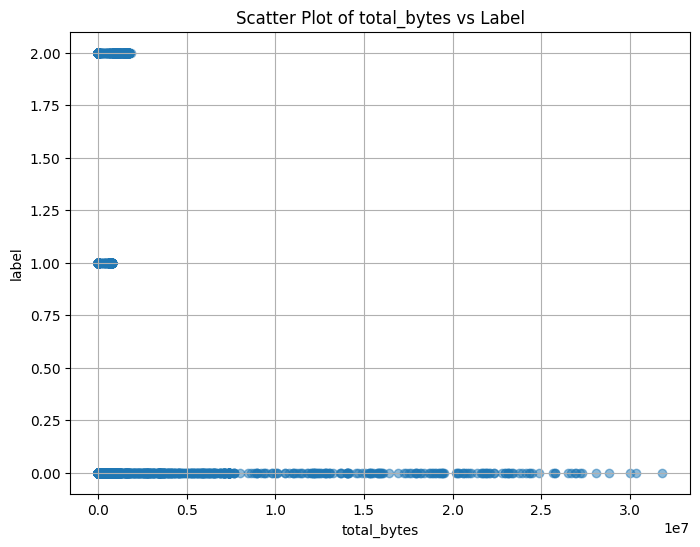

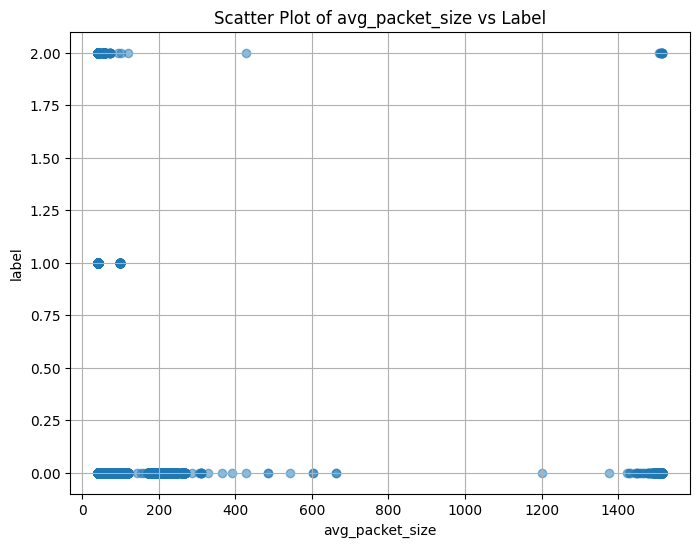

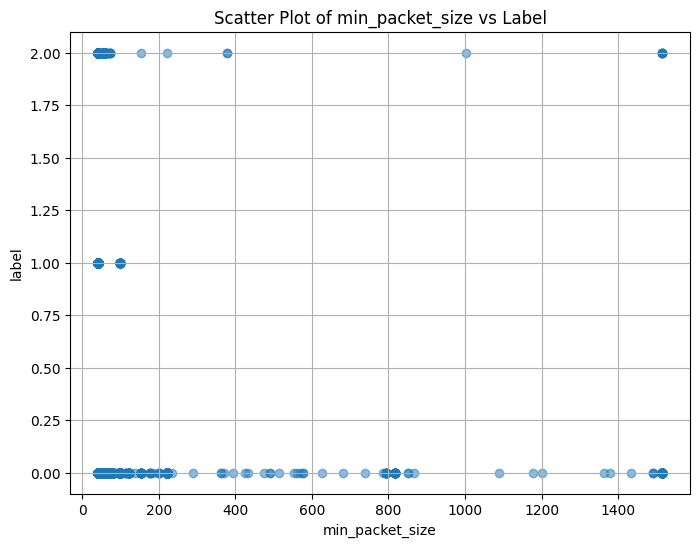

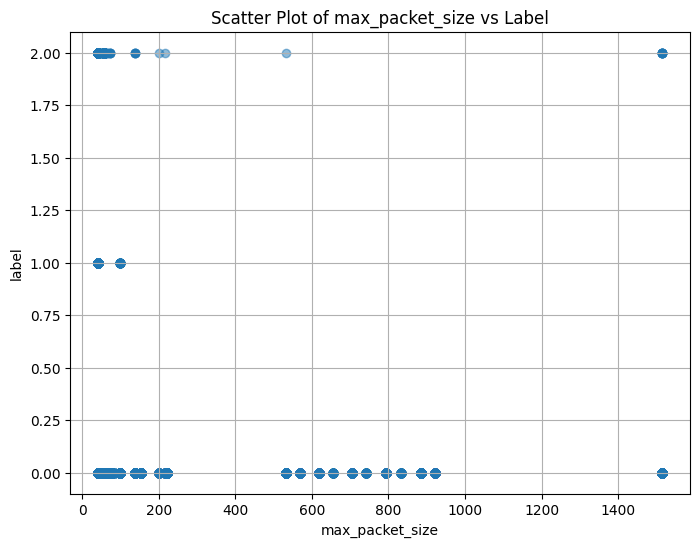

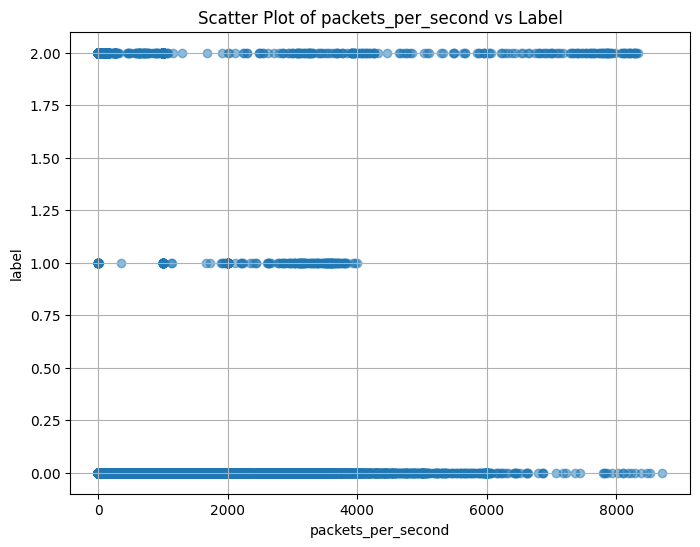

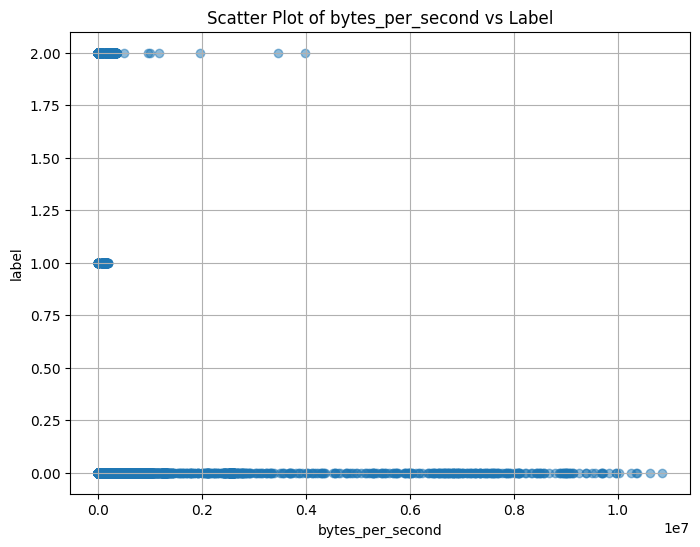

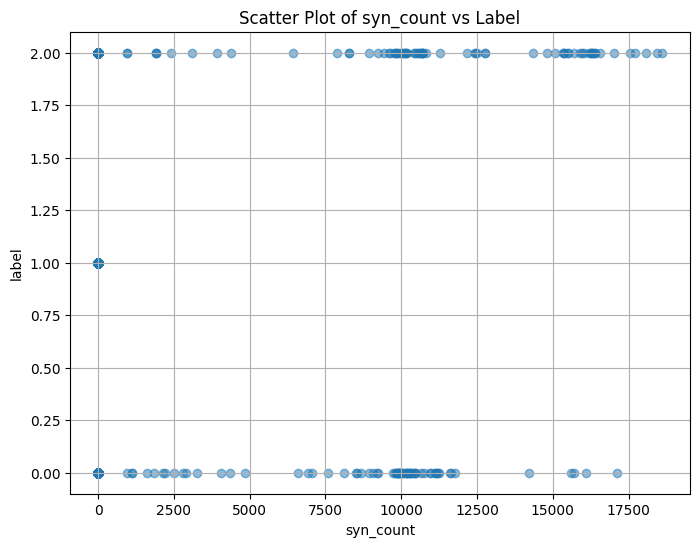

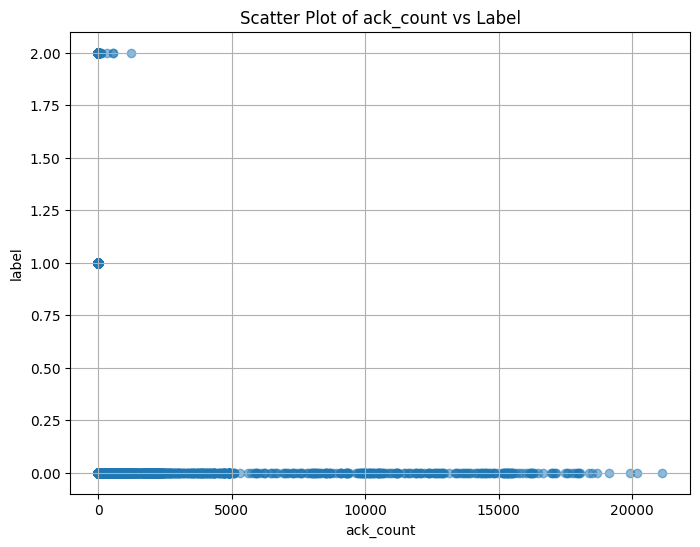

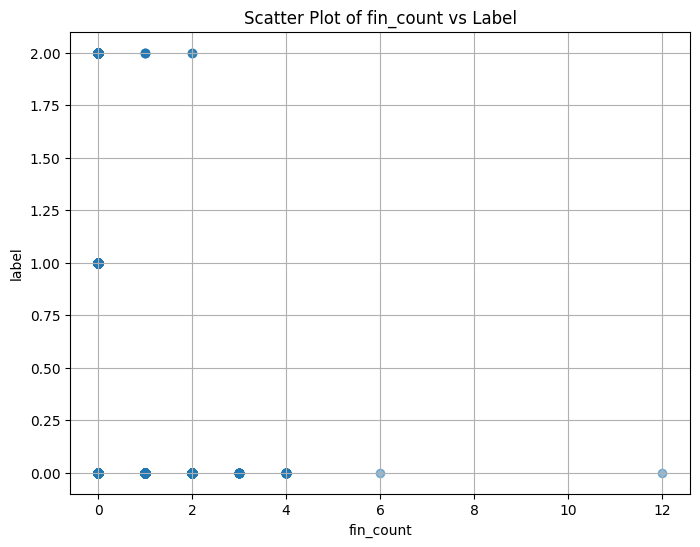

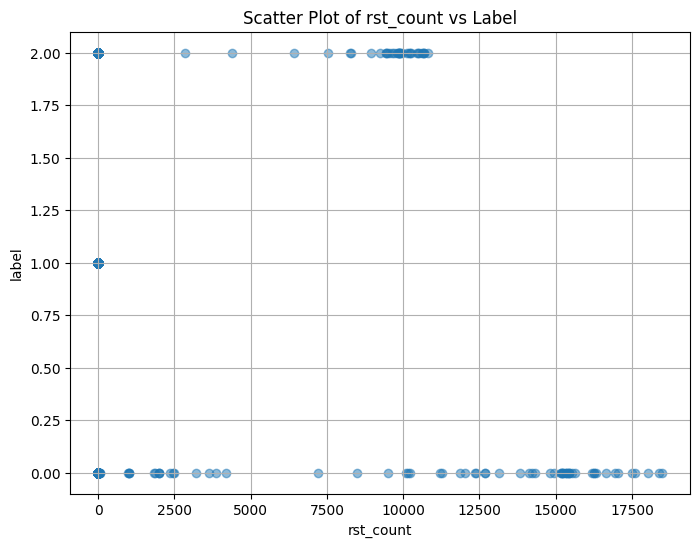

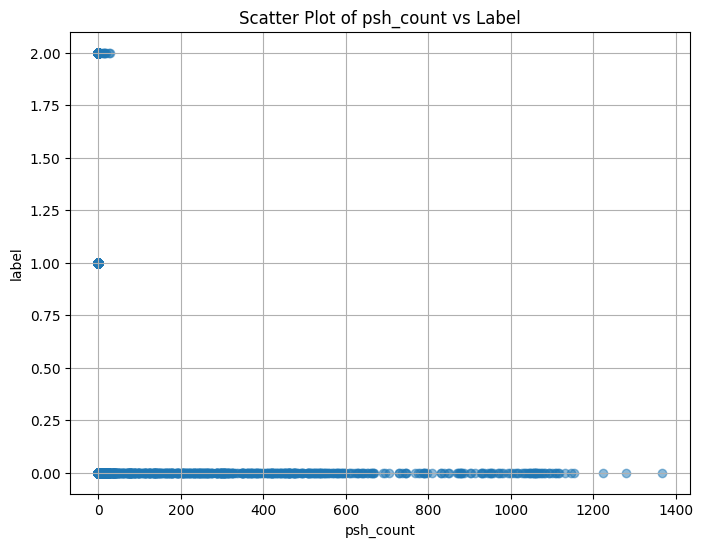

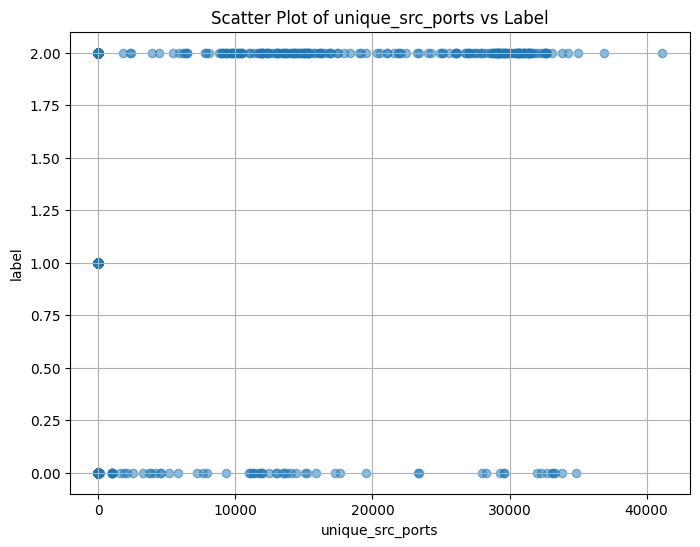

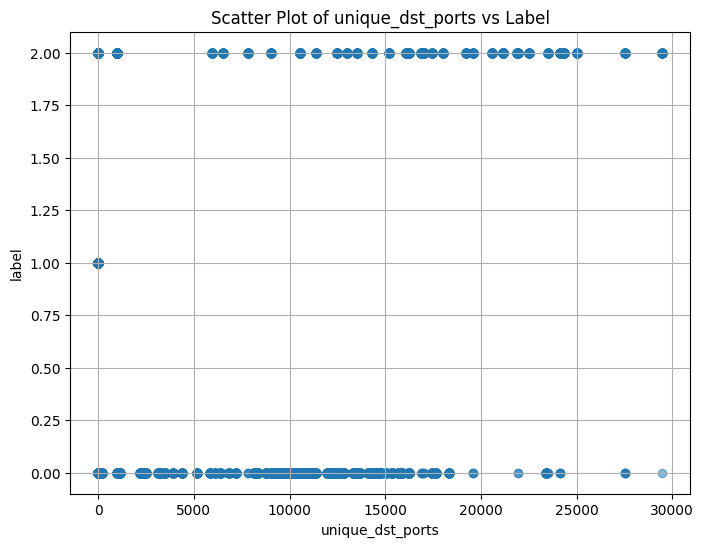

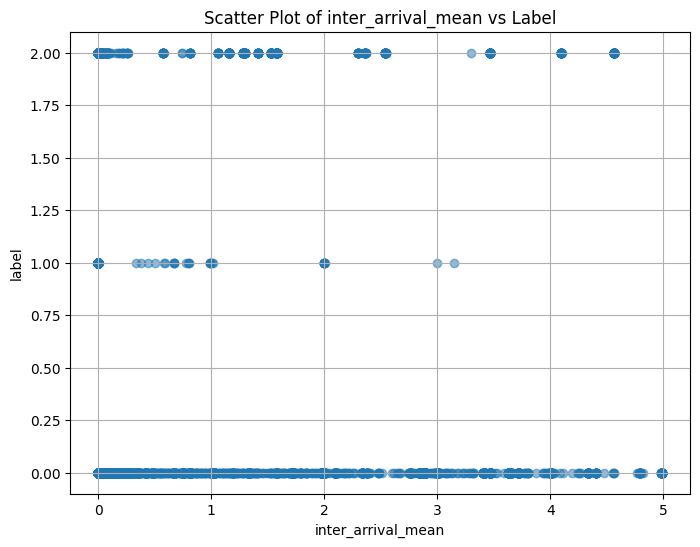

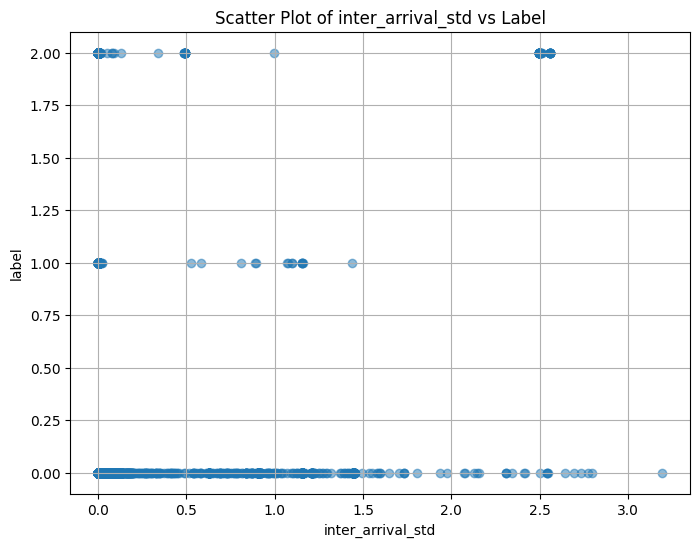

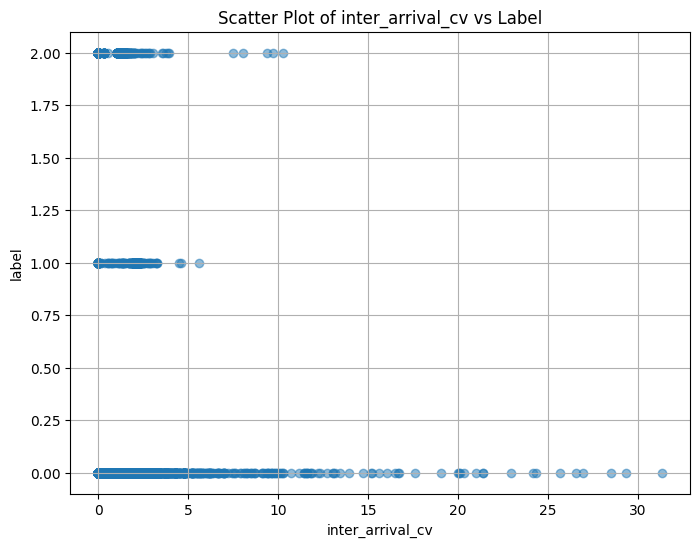

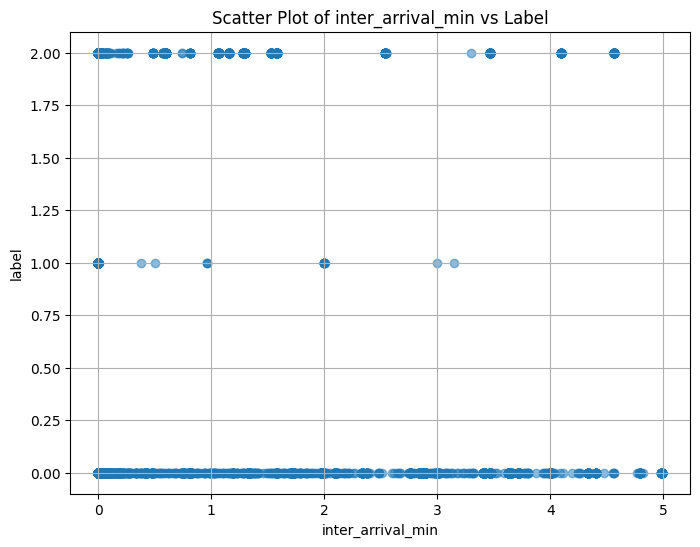

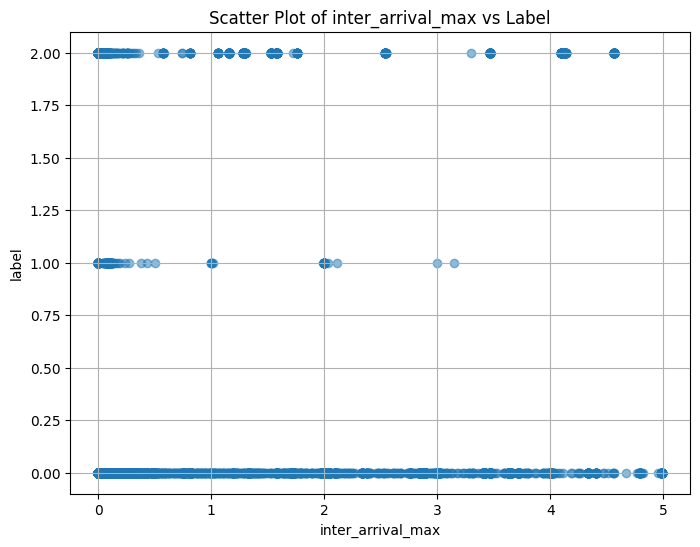

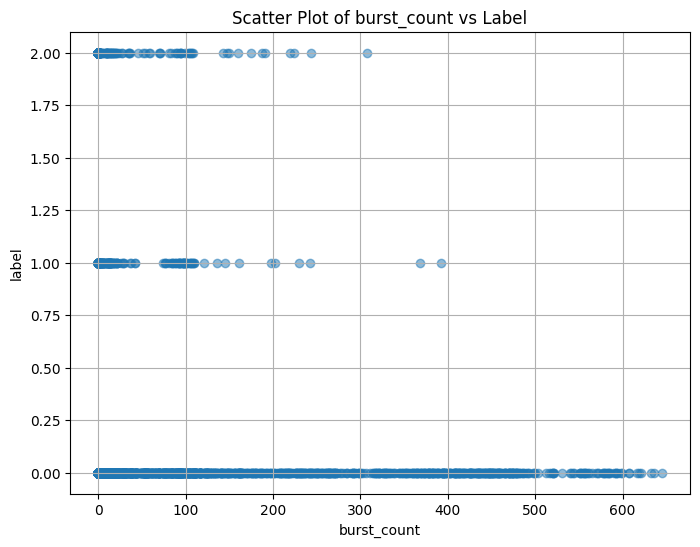

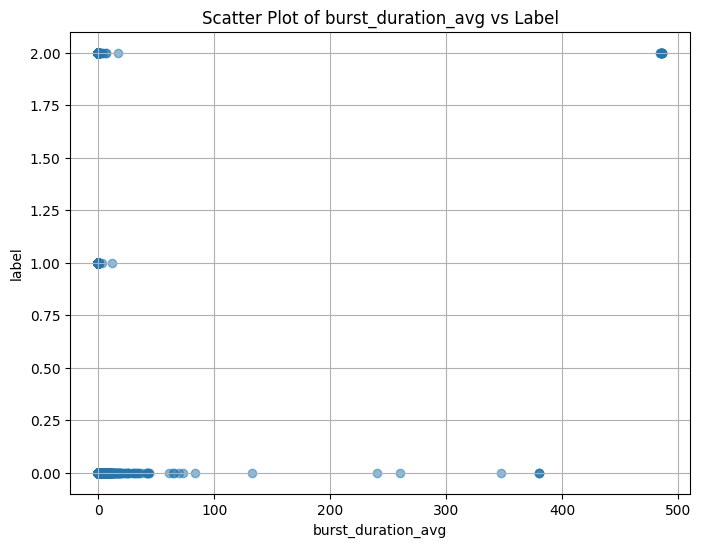

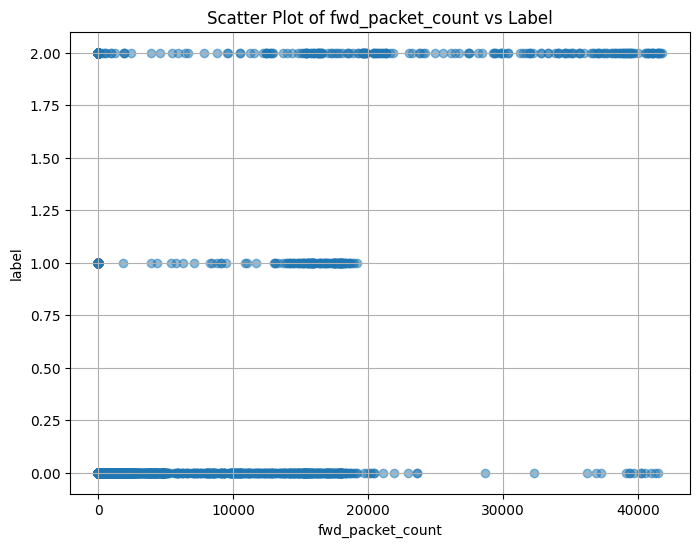

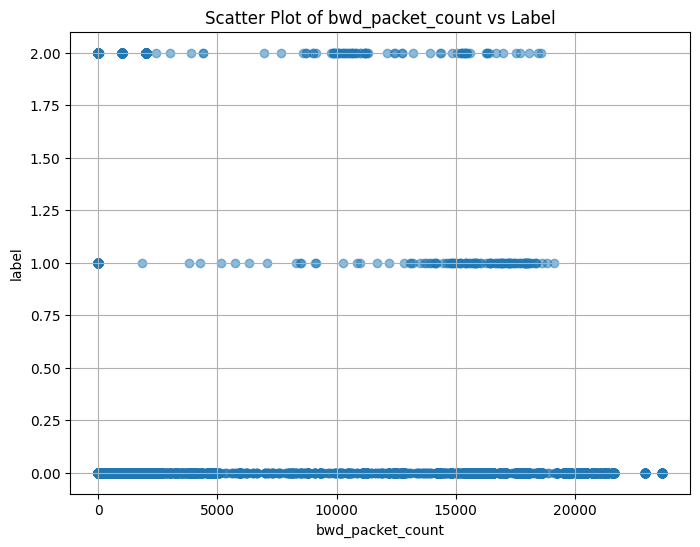

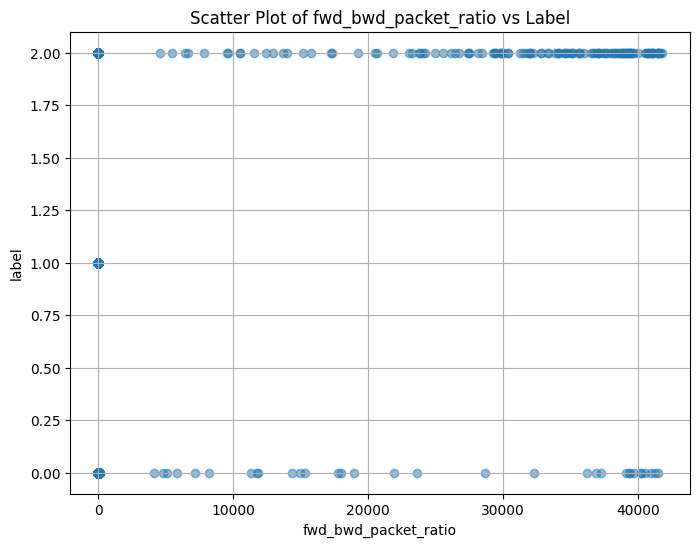

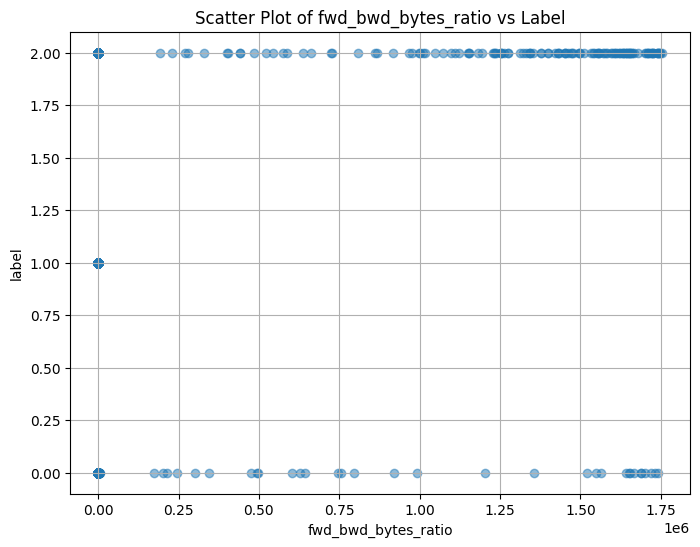

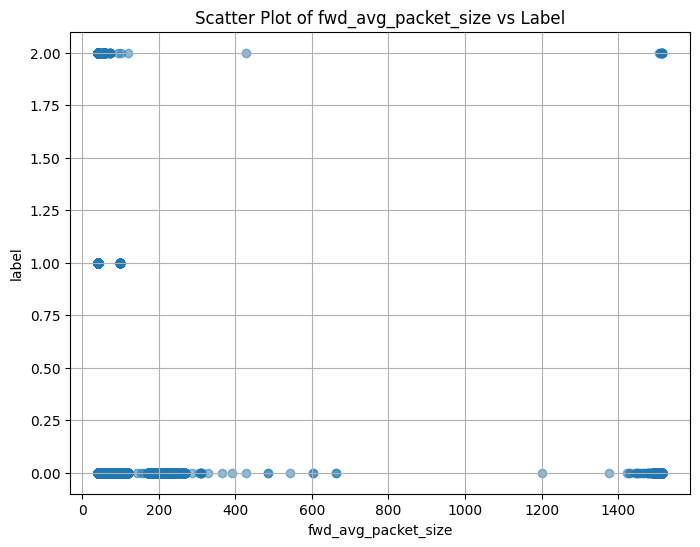

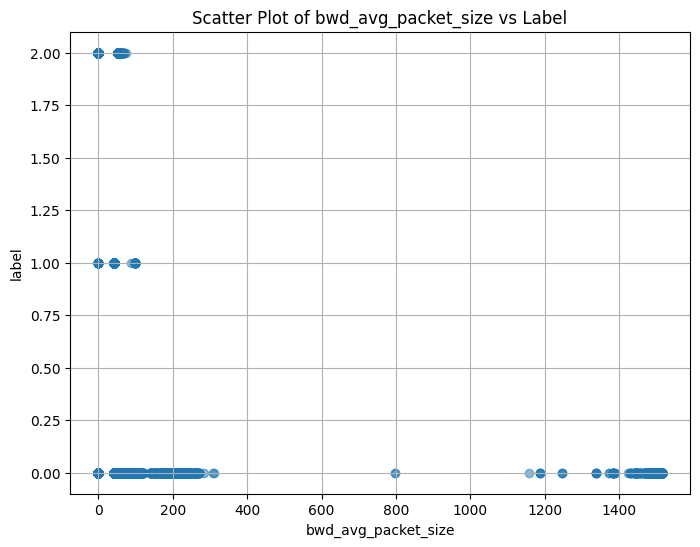

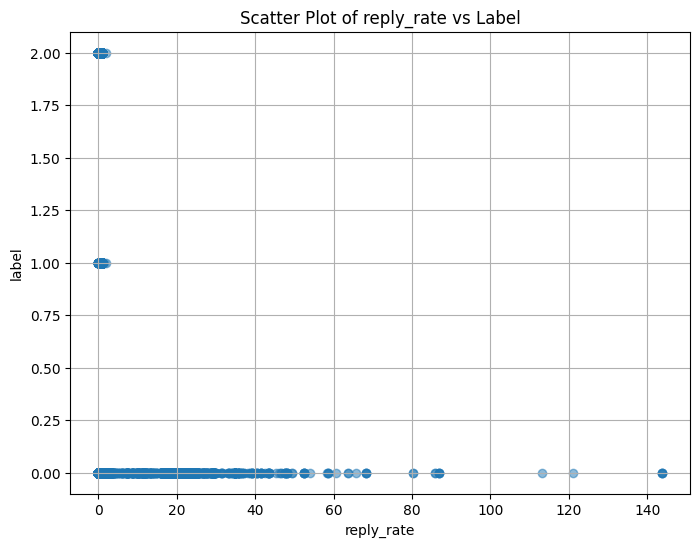

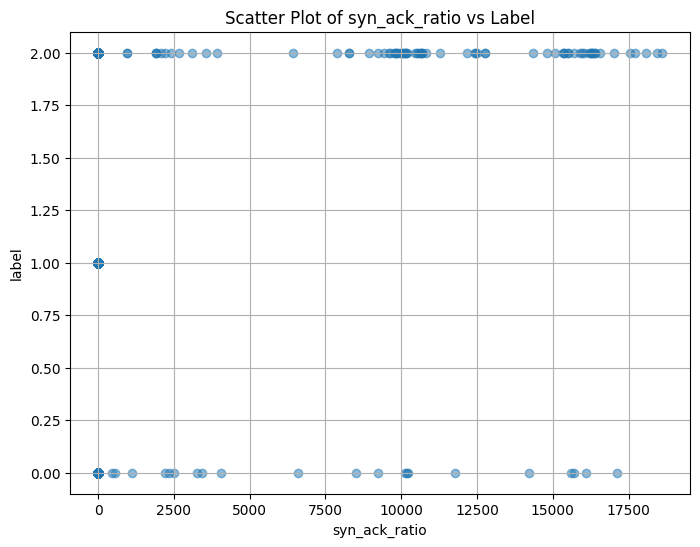

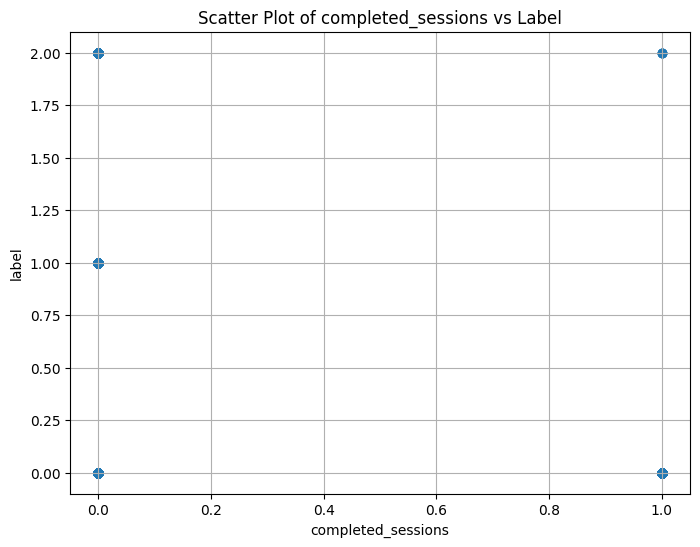

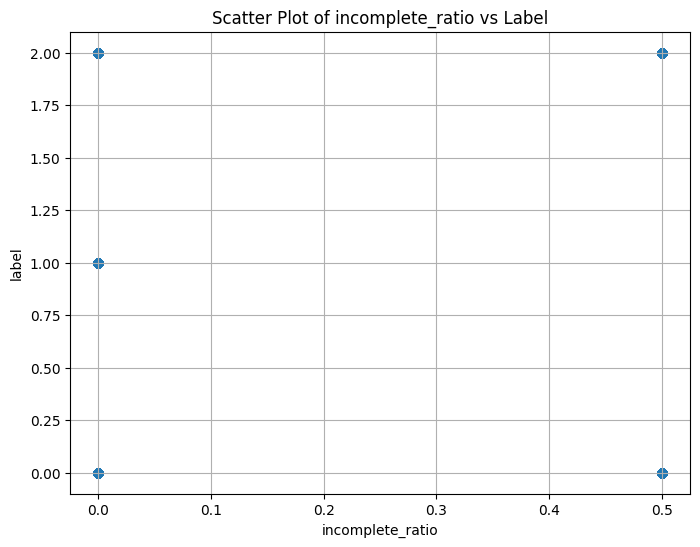

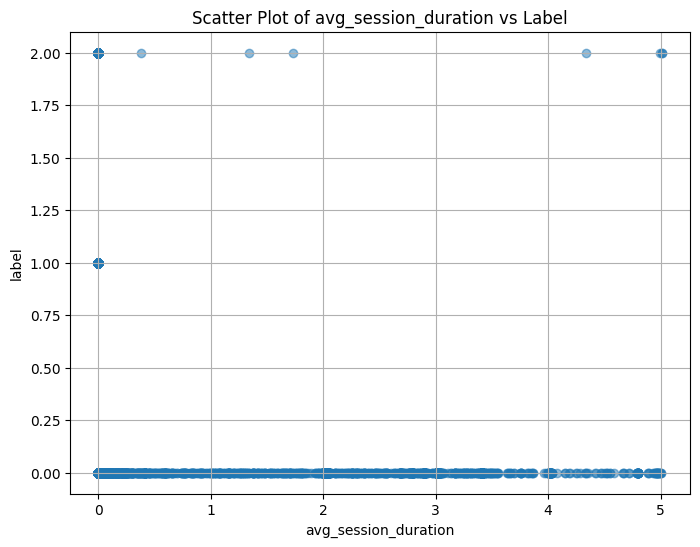

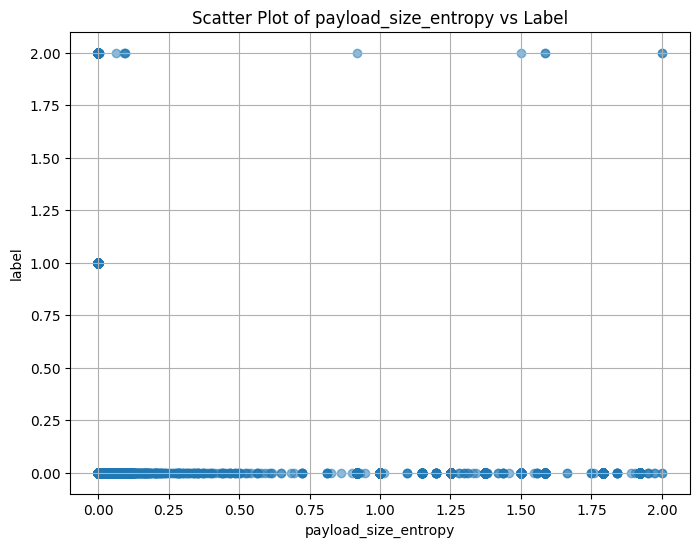

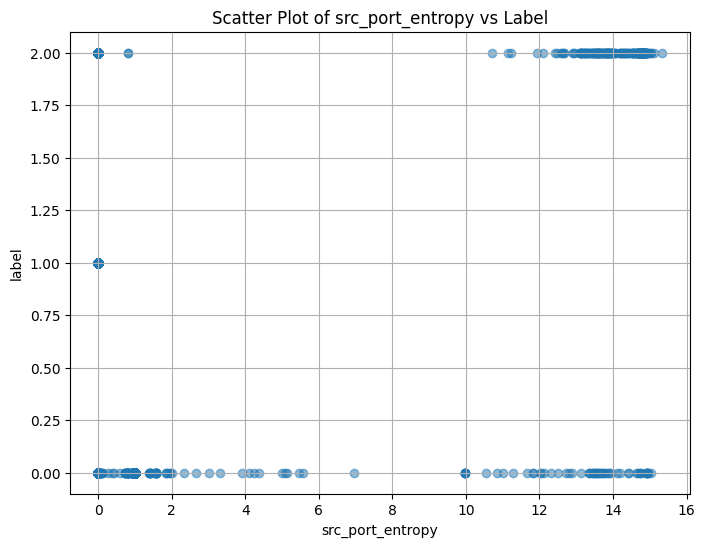

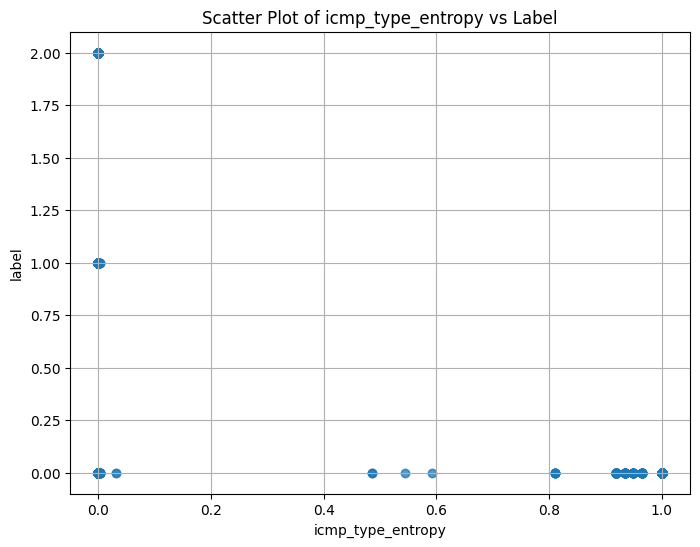

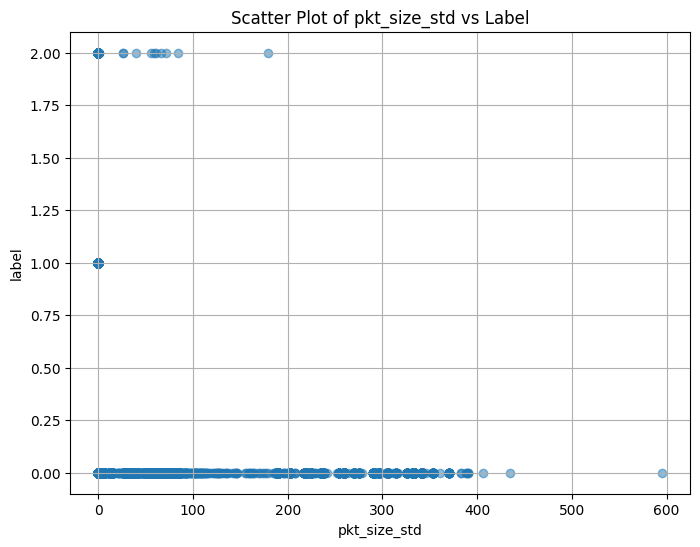

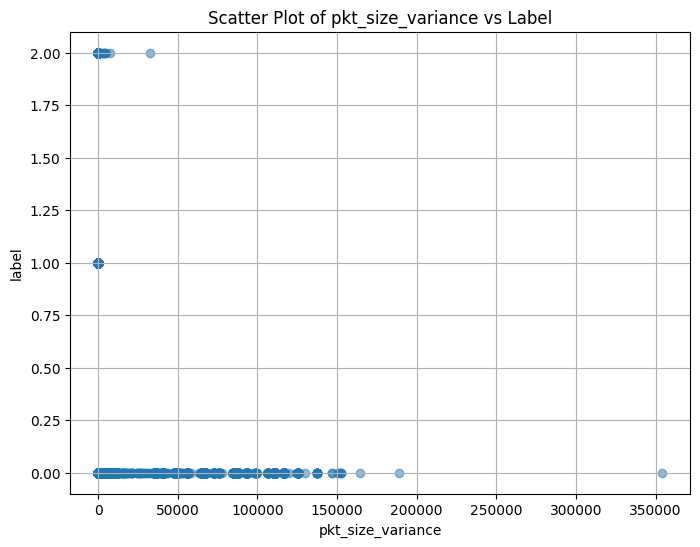

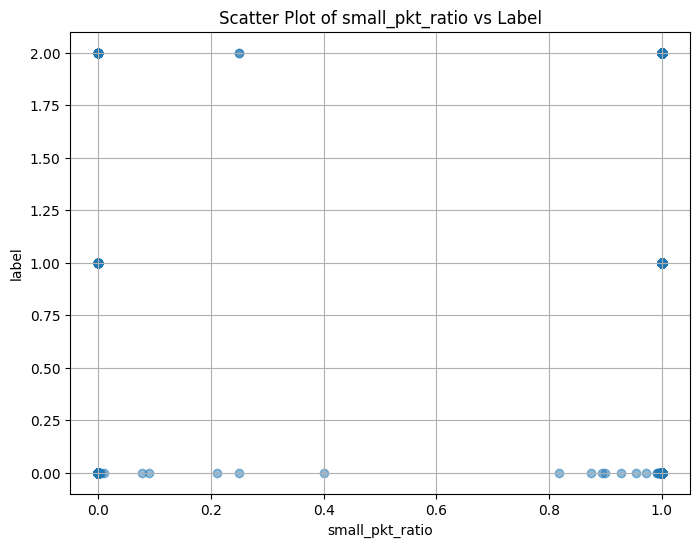

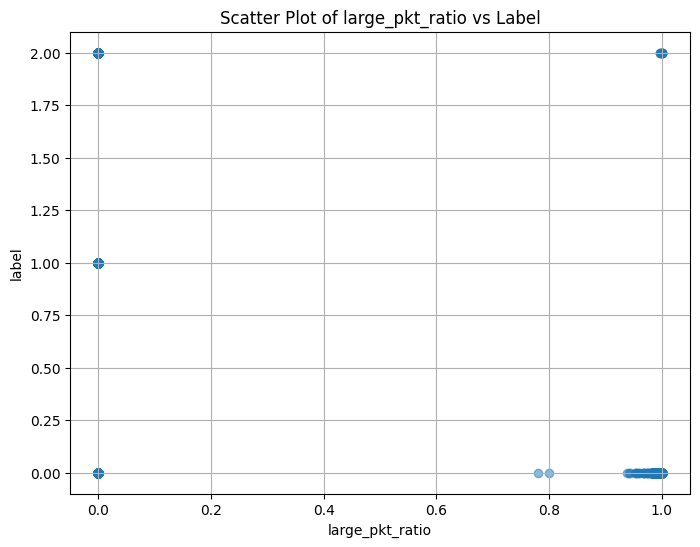

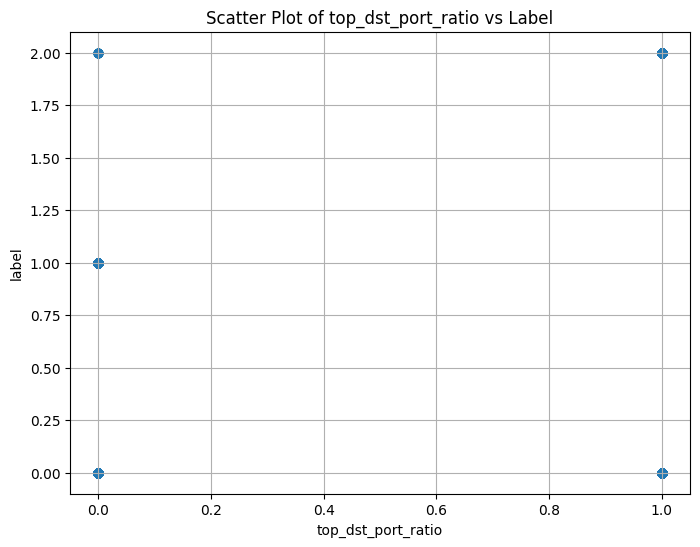

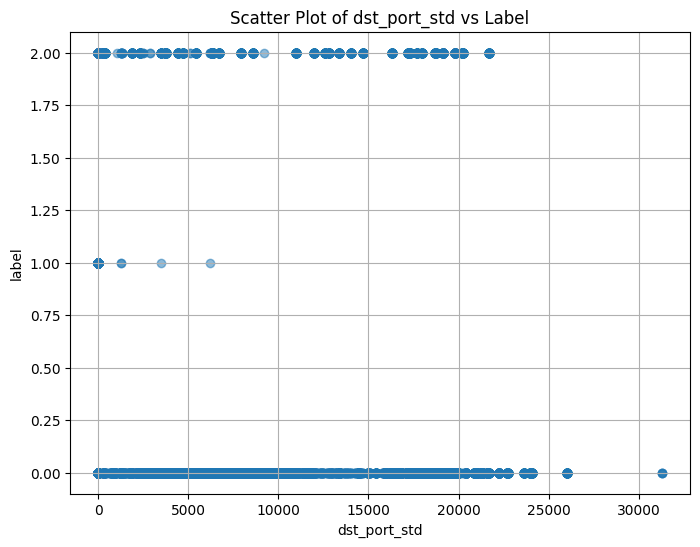

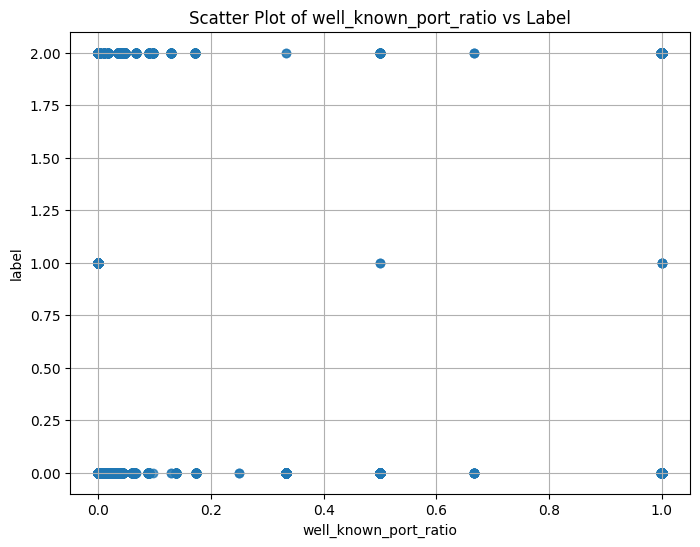

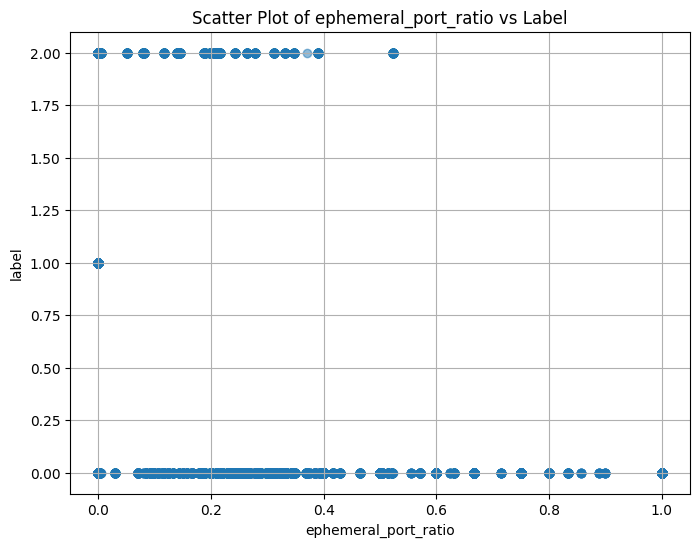

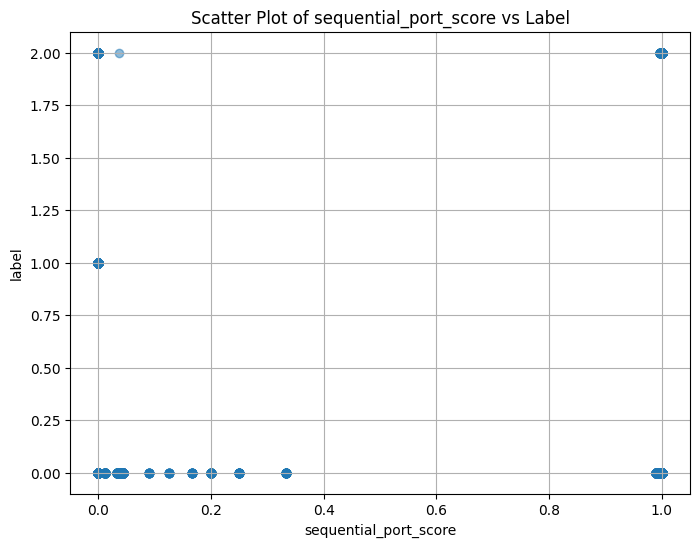

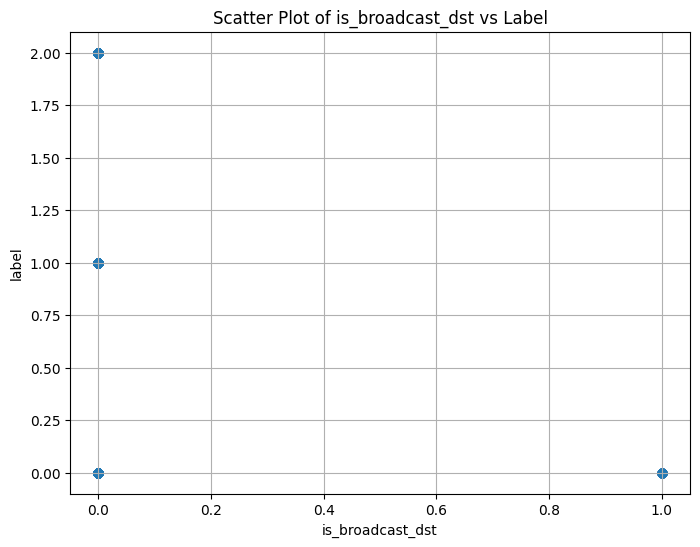

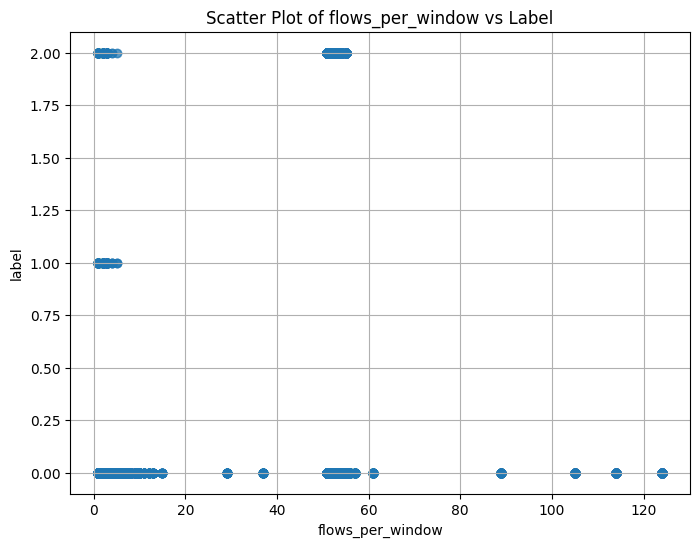

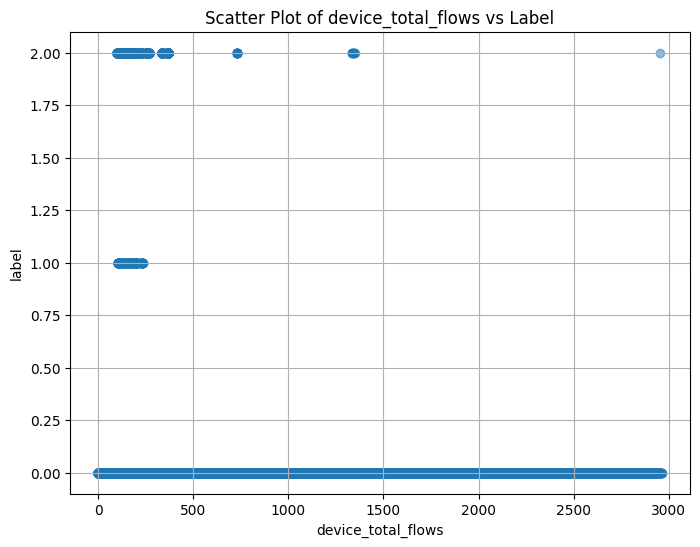

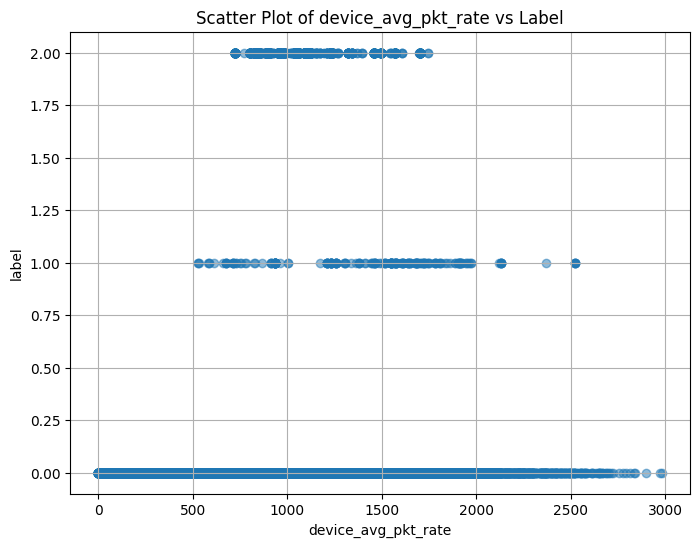

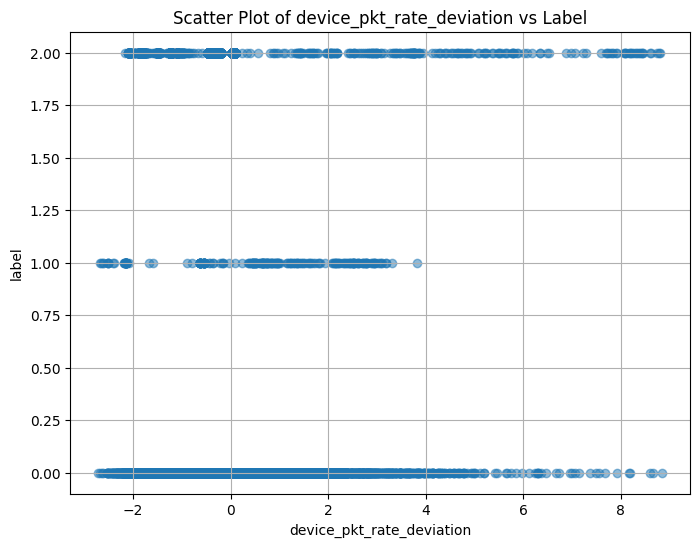

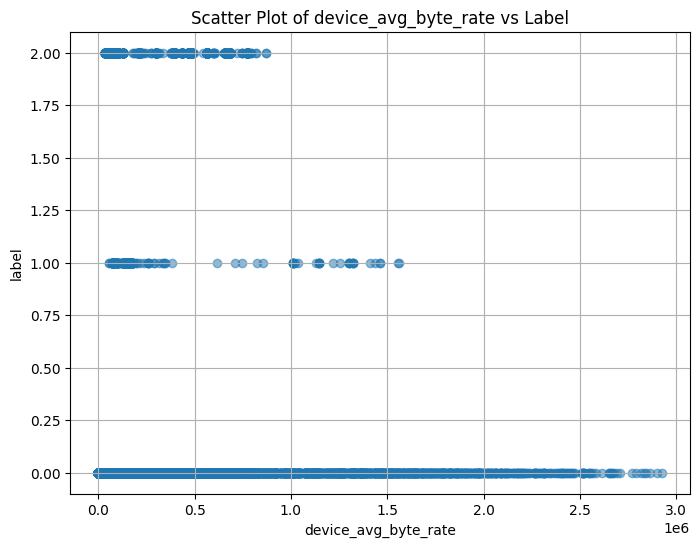

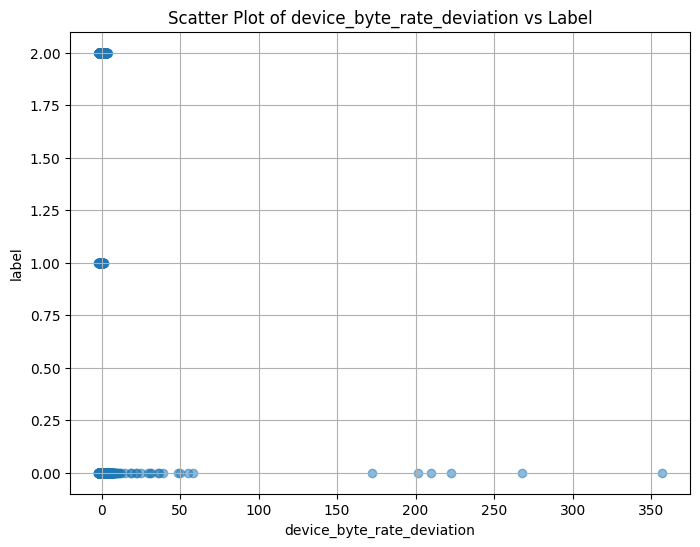

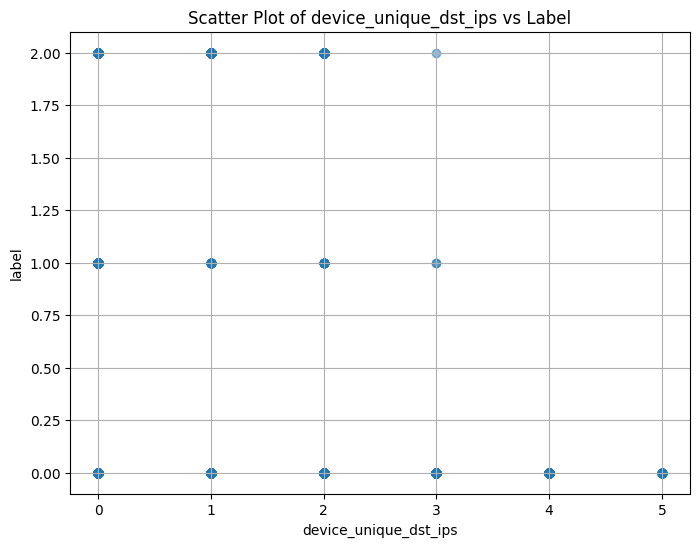

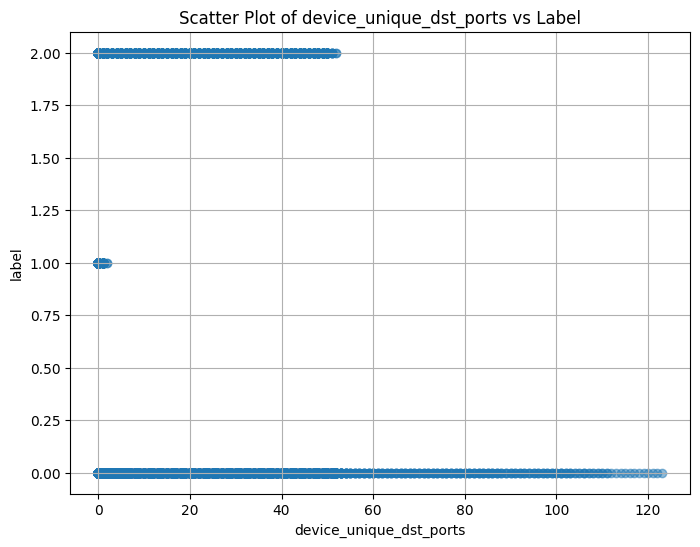

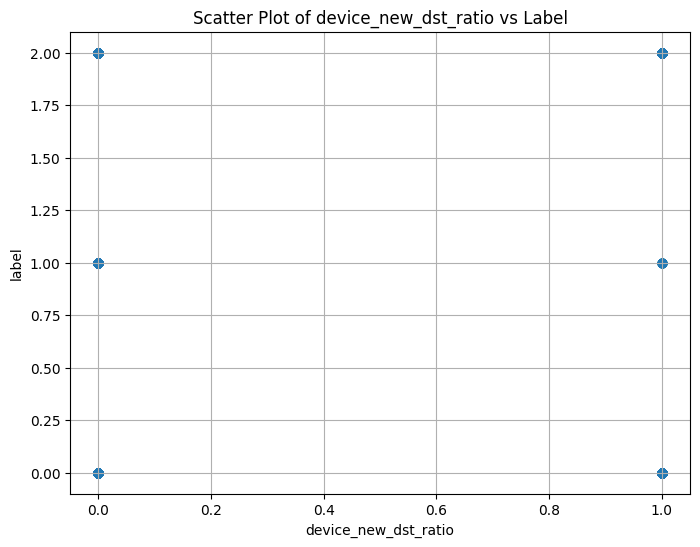

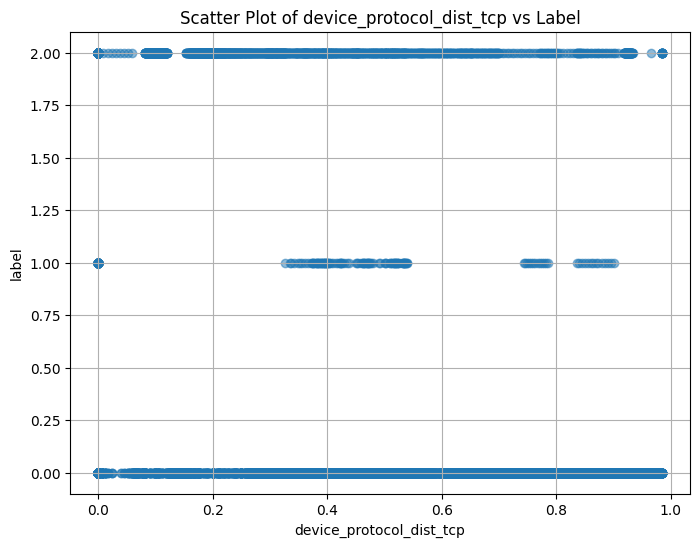

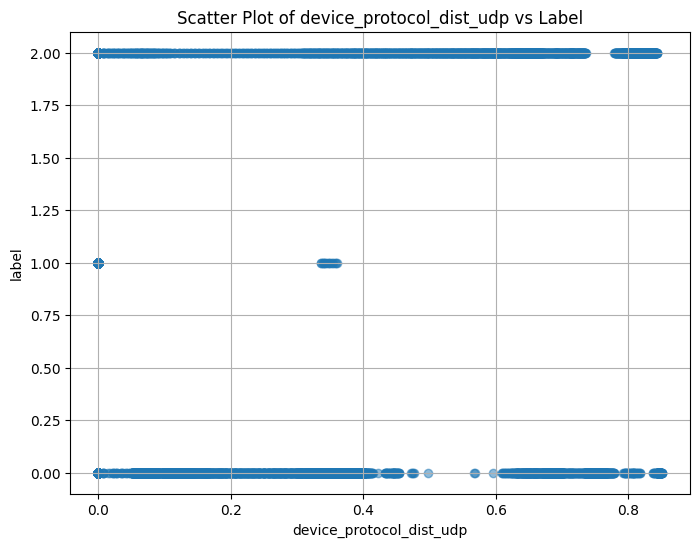

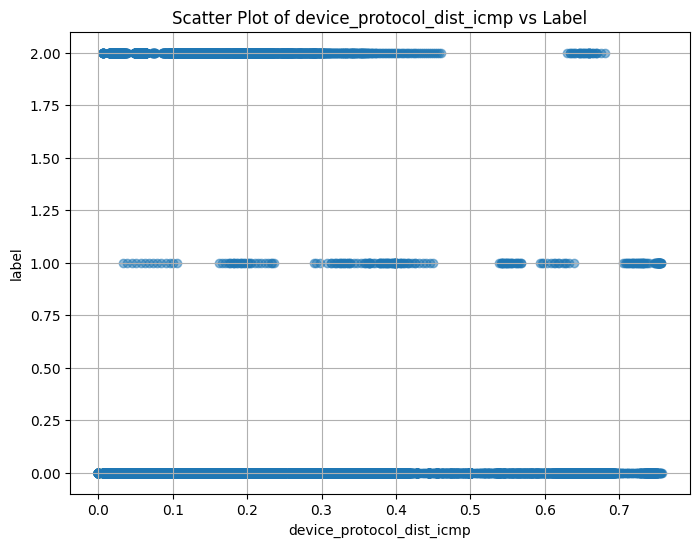

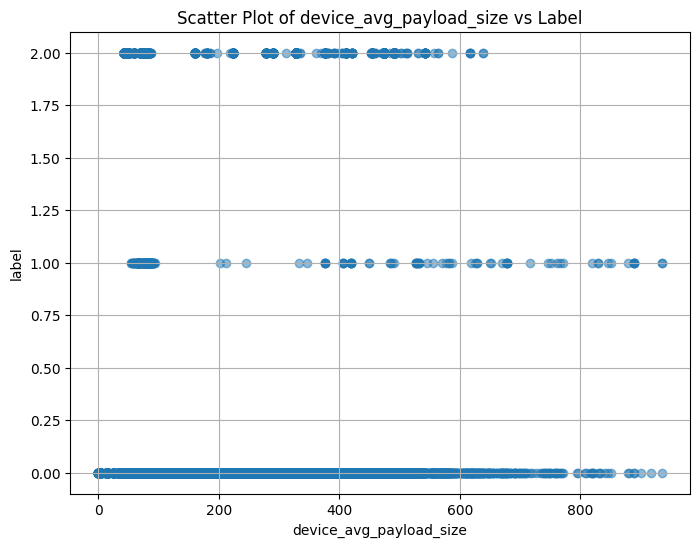

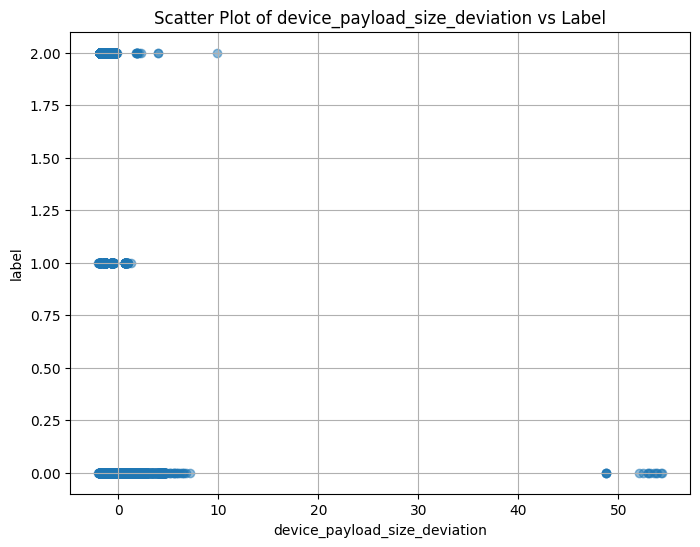

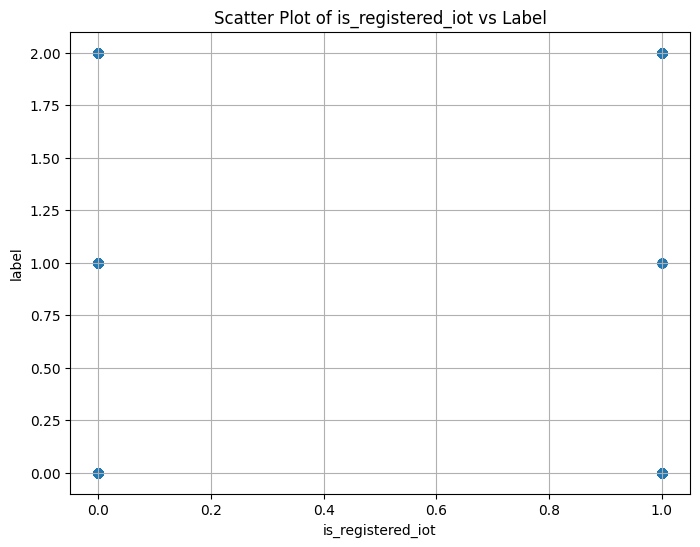

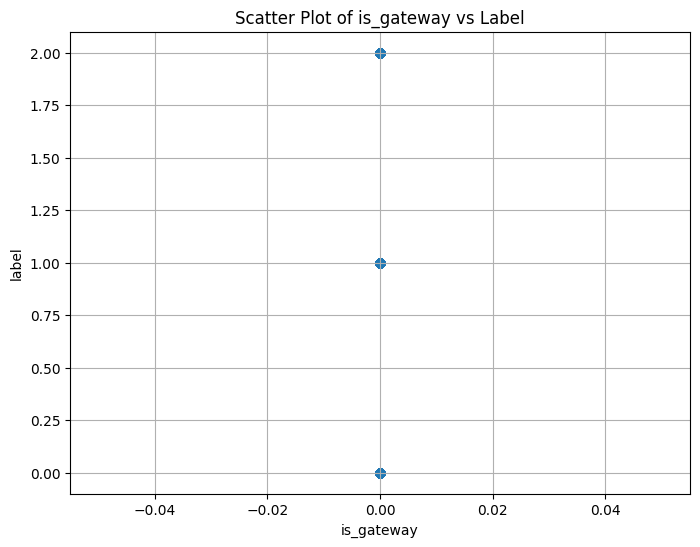

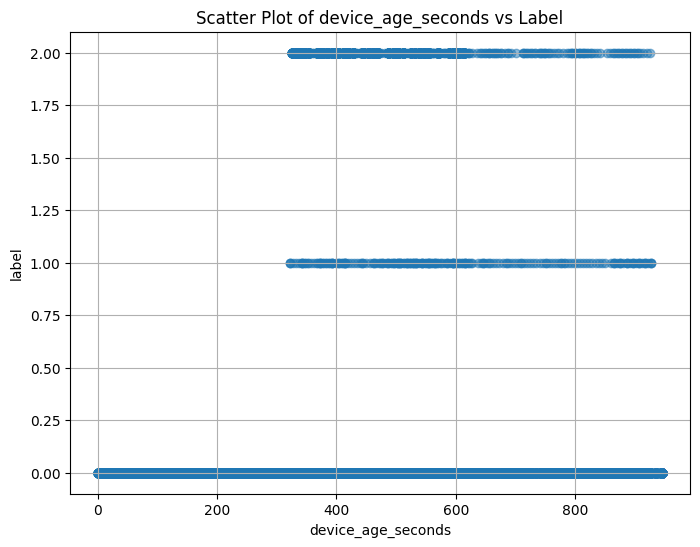

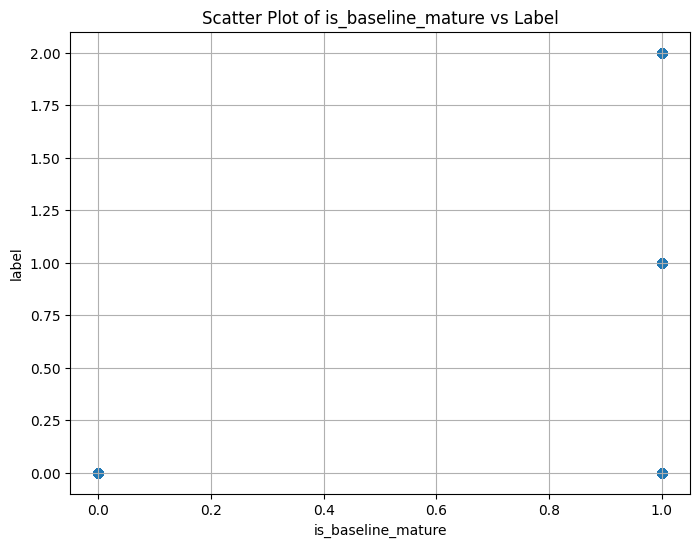

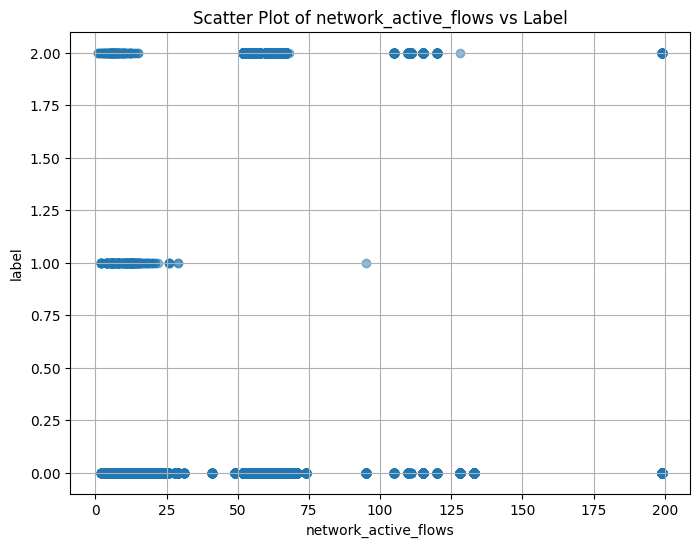

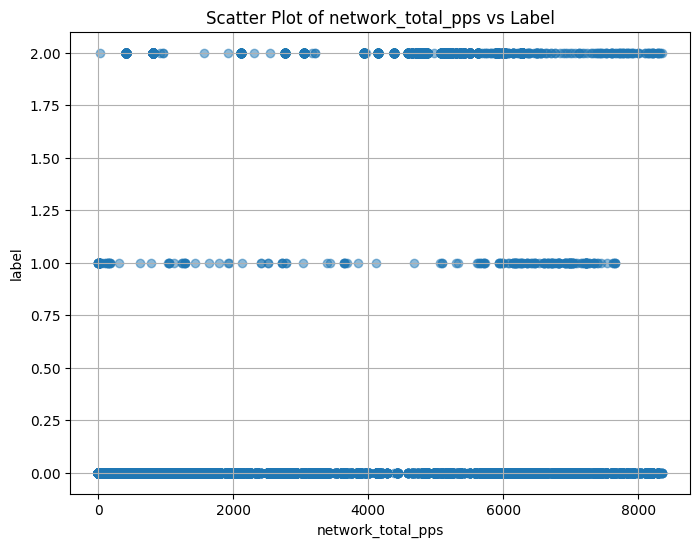

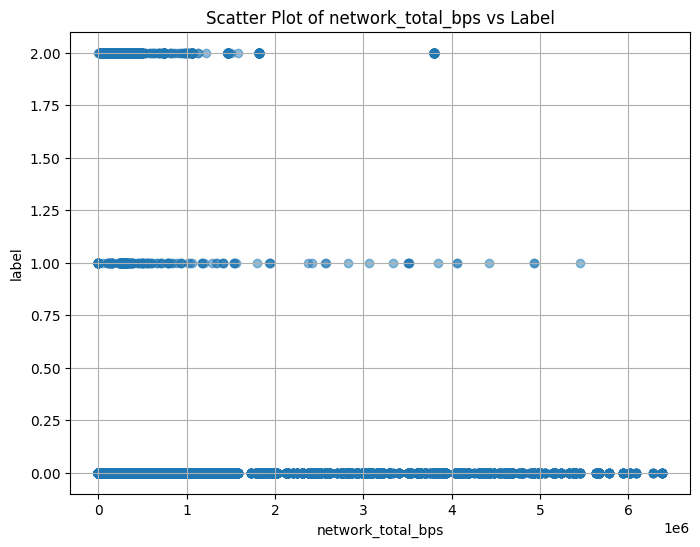

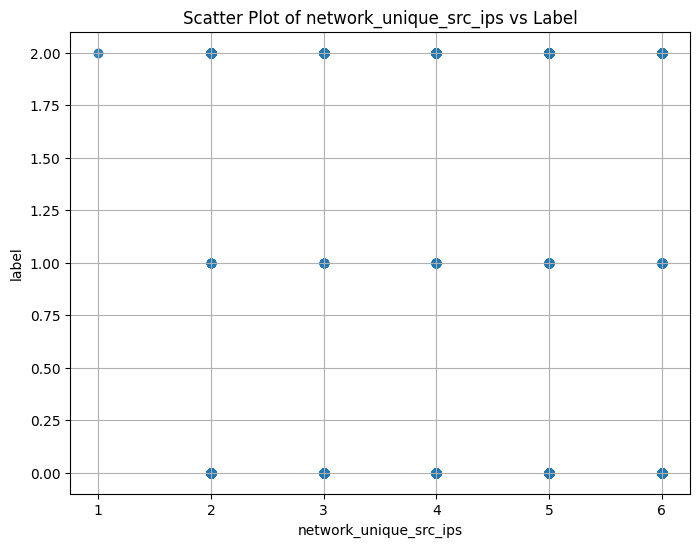

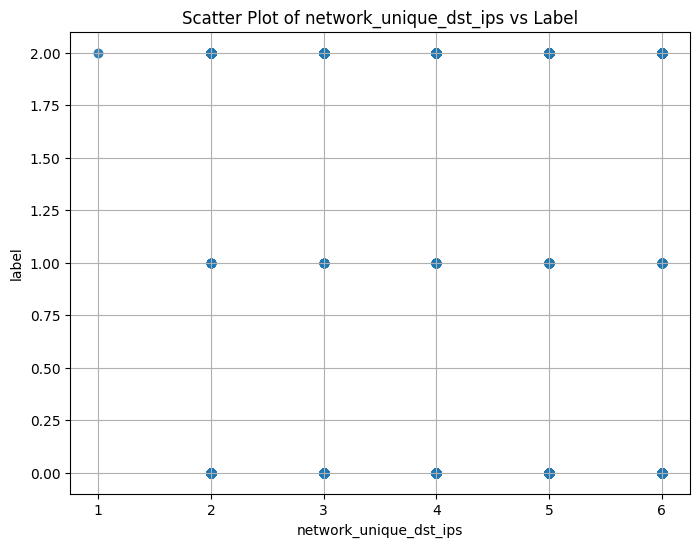

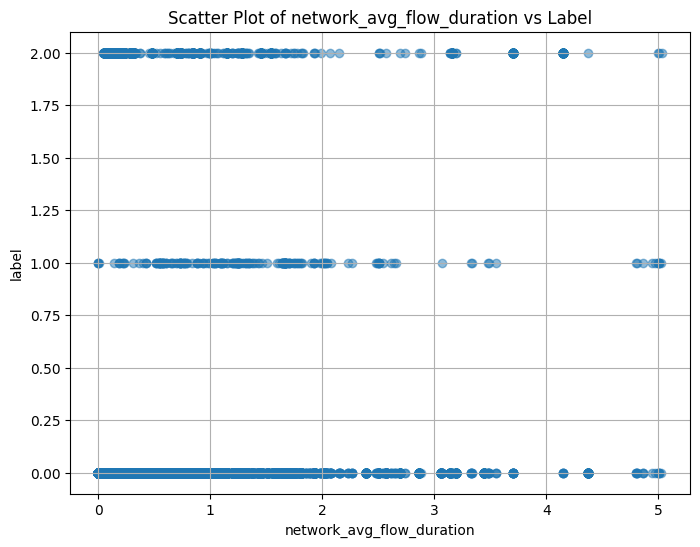

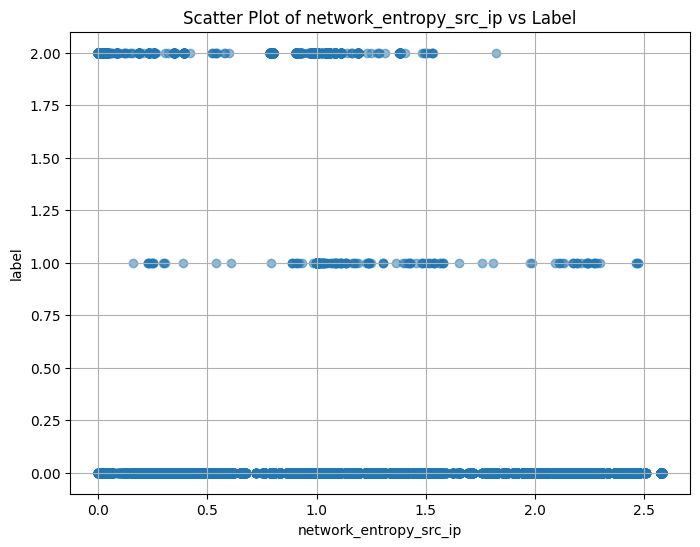

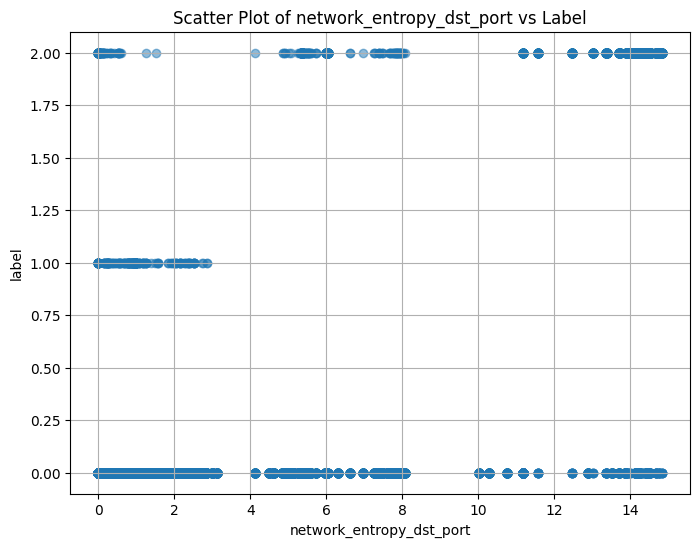

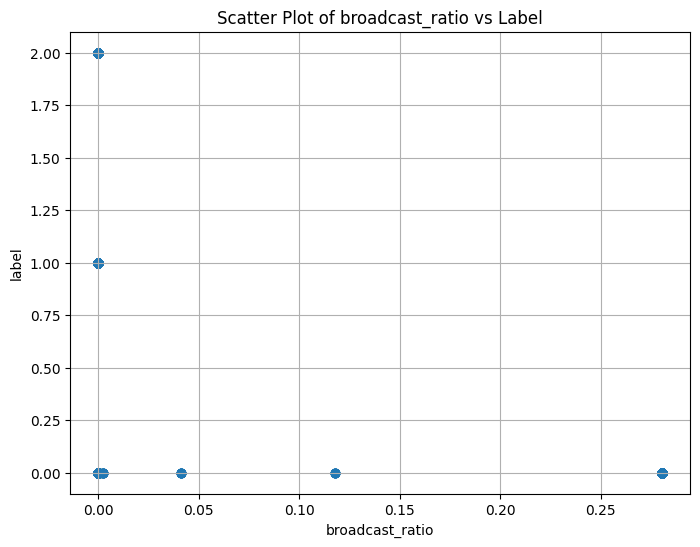

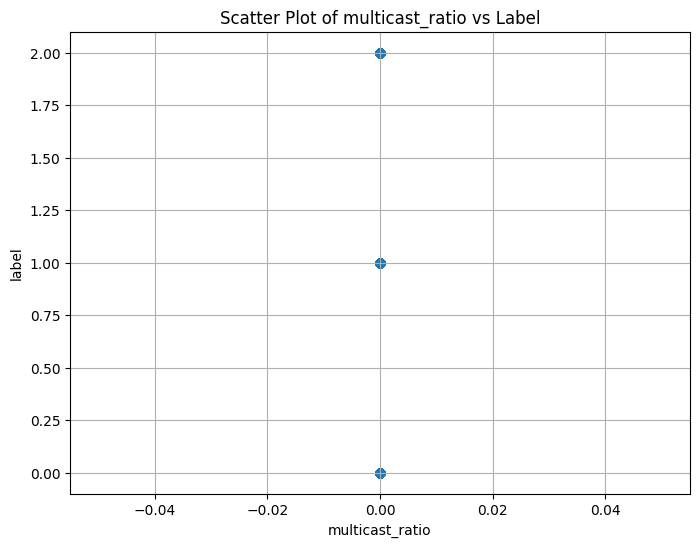

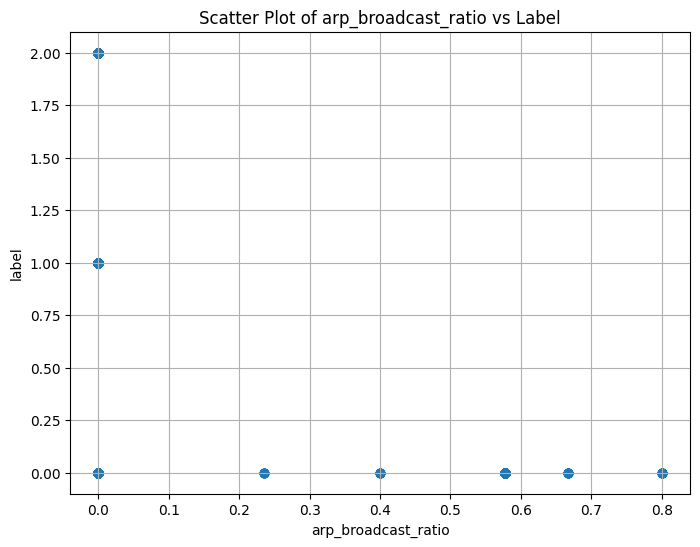

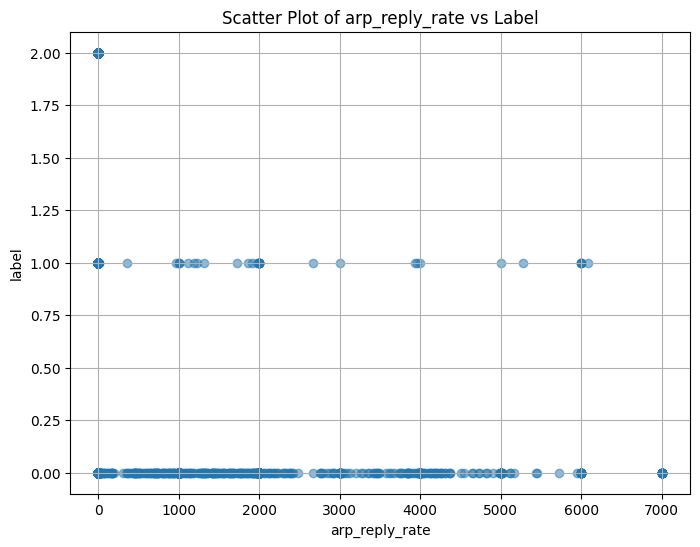

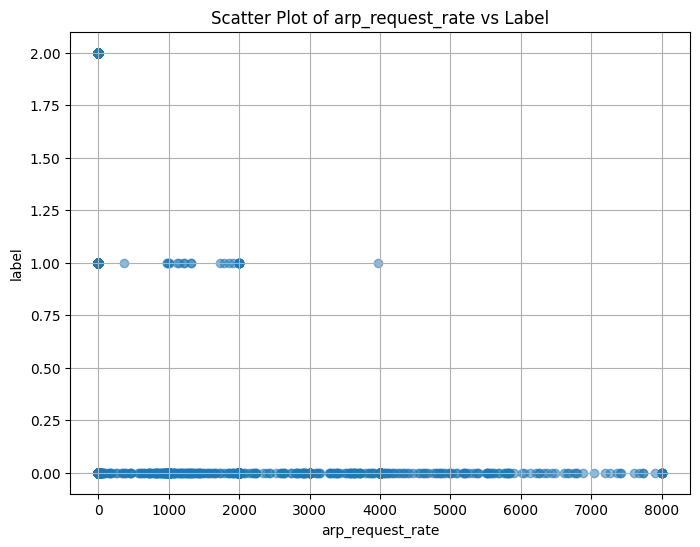

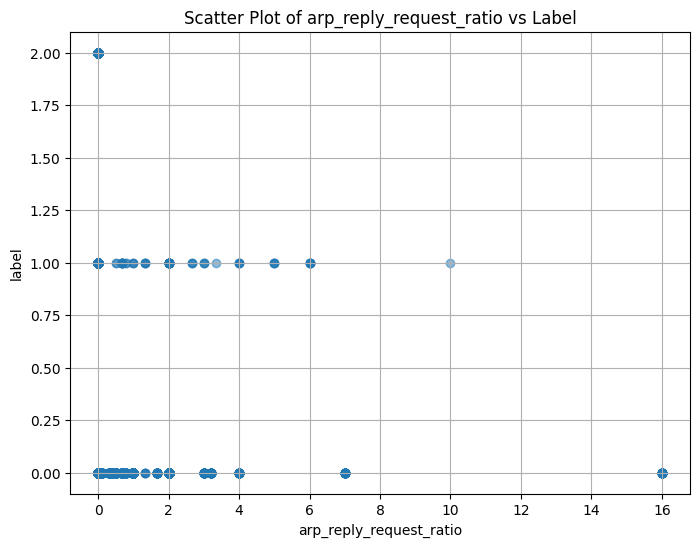

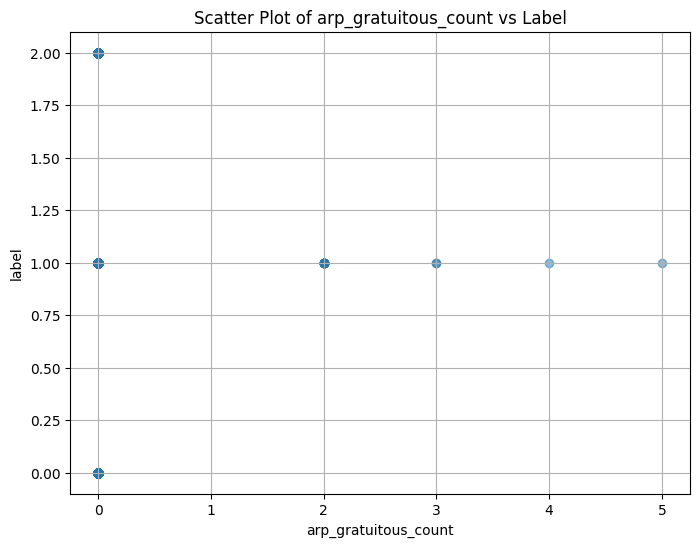

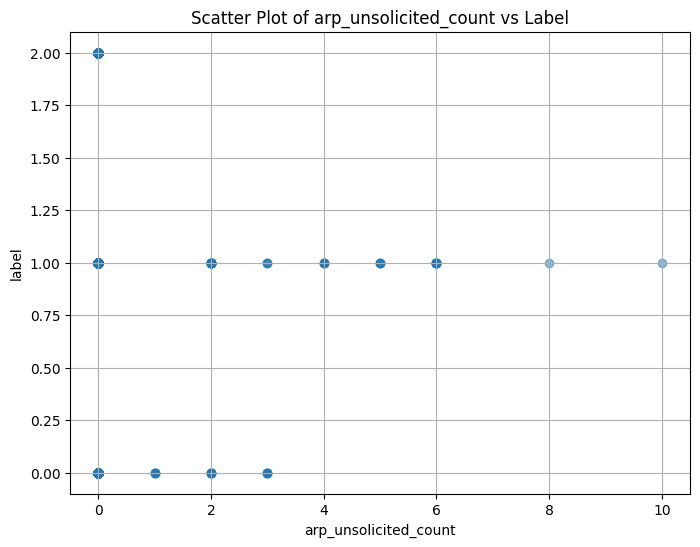

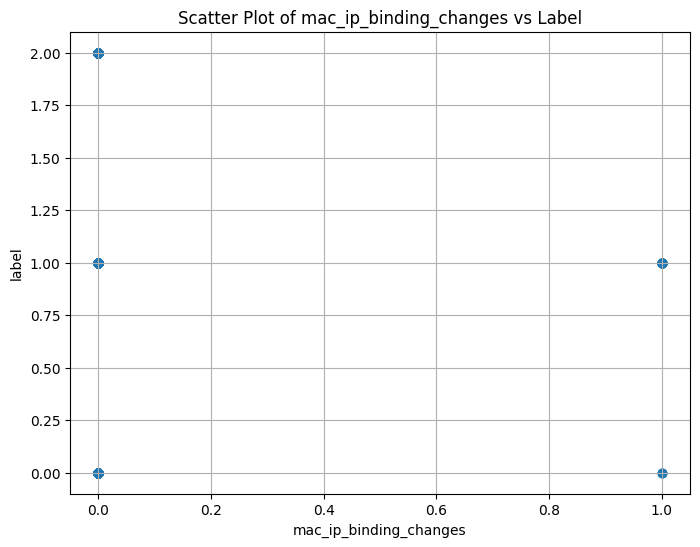

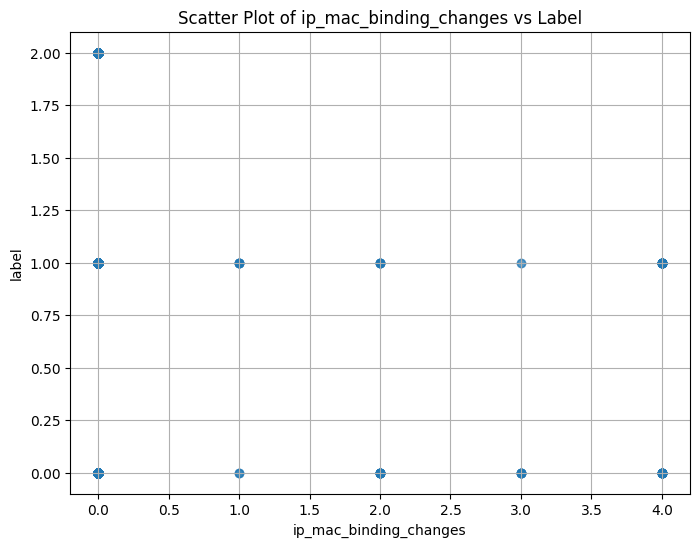

In [ ]:
import matplotlib.pyplot as plt

# Exclude 'label', 'attack_type' and 'protocol' from features for scatter plots
features_for_plotting = [col for col in data_1.columns if col not in ['label', 'attack_type', 'protocol']]

for feature in features_for_plotting:
    # Ensure the feature is numerical before attempting to plot
    if pd.api.types.is_numeric_dtype(data_1[feature]):
        plt.figure(figsize=(8, 6))
        plt.scatter(data_1[feature], data_1['label'], alpha=0.5)
        plt.xlabel(feature)
        plt.ylabel('label')
        plt.title(f'Scatter Plot of {feature} vs Label')
        plt.grid(True)
        plt.show()
    else:
        print(f"Skipping non-numerical feature '{feature}' for scatter plot.")

#Data preprocessing

In [ ]:
#Creating features and labels
x= data_1.drop("label", axis=1)
x= x.drop("attack_type", axis=1)
y= data_1["label"]
y1 = data_1["attack_type"]
#Checking missing data in the features
pd.set_option('display.max_rows', None)
print(x.isna().sum())
pd.reset_option('display.max_rows')

protocol                         0
flow_duration                    0
total_packets                    0
total_bytes                      0
avg_packet_size                  0
min_packet_size                  0
max_packet_size                  0
packets_per_second               0
bytes_per_second                 0
syn_count                        0
ack_count                        0
fin_count                        0
rst_count                        0
psh_count                        0
unique_src_ports                 0
unique_dst_ports                 0
inter_arrival_mean               0
inter_arrival_std                0
inter_arrival_cv                 0
inter_arrival_min                0
inter_arrival_max                0
burst_count                      0
burst_duration_avg               0
fwd_packet_count                 0
bwd_packet_count                 0
fwd_bwd_packet_ratio             0
fwd_bwd_bytes_ratio              0
fwd_avg_packet_size              0
bwd_avg_packet_size 

In [ ]:
#Checking missing data in the labels
print(y1.isna().sum())
print(y.isna().sum())

0
0


In [ ]:
#Checking the features and labels that needed to be encoded
for i in feature_dict:
  print(i,data_1[i].value_counts())

protocol protocol
TCP     11859
ICMP     3311
UDP      3023
ARP      1339
Name: count, dtype: int64
flow_duration flow_duration
0.0010    11456
0.0020      104
0.0019      101
0.0018       96
0.0017       87
          ...  
1.5709        1
1.5707        1
1.5705        1
1.5917        1
1.9886        1
Name: count, Length: 3861, dtype: int64
total_packets total_packets
1        9619
2        4317
6        1147
10        795
4         492
         ... 
30071       1
654         1
17742       1
27465       1
9986        1
Name: count, Length: 1522, dtype: int64
total_bytes total_bytes
54         2492
58         2008
42         1928
196        1278
84         1273
           ... 
82962         1
3989586       1
88390         1
3411718       1
19140         1
Name: count, Length: 1947, dtype: int64
avg_packet_size avg_packet_size
42.00      3973
54.00      3171
58.00      2631
98.00      2393
66.00       793
           ... 
1448.36       1
67.43         1
1509.69       1
1511.11       1
89

## One Hot Encoder

In [ ]:
# One-hot encode the 'protocol' (x)
x_encoded = pd.get_dummies(x, prefix='protocol')
x_encoded.head()

,flow_duration,total_packets,total_bytes,avg_packet_size,min_packet_size,max_packet_size,packets_per_second,bytes_per_second,syn_count,ack_count,...,arp_request_rate,arp_reply_request_ratio,arp_gratuitous_count,arp_unsolicited_count,mac_ip_binding_changes,ip_mac_binding_changes,protocol_ARP,protocol_ICMP,protocol_TCP,protocol_UDP
0,0.0049,4,168,42.0,42,42,808.3457,33950.5214,0,0,...,4041.7287,0.0000,0,0,0,0,True,False,False,False
1,0.0025,2,84,42.0,42,42,810.8069,34053.8890,0,0,...,6486.4551,0.1176,0,0,0,0,True,False,False,False
2,0.0961,3,294,98.0,98,98,31.2296,3060.5024,0,0,...,0.0000,0.0000,0,0,0,0,False,True,False,False
3,0.0934,2,196,98.0,98,98,21.4070,2097.8852,0,0,...,0.0000,0.0000,0,0,0,0,False,True,False,False
4,0.0069,4,168,42.0,42,42,580.2454,24370.3075,0,0,...,2901.2271,0.0000,0,0,0,0,True,False,False,False


In [ ]:
# One-hot encode the 'attack_type' label (y1)
y1_encoded = pd.get_dummies(y1, prefix='attack_type')
y1_encoded.head()

,attack_type_ARP Spoofing,attack_type_Control Plane Saturation,attack_type_ICMP Flood,attack_type_Port Scan,attack_type_SYN Flood,attack_type_UDP Flood,attack_type_normal
0,False,False,False,False,False,False,True
1,False,False,False,False,False,False,True
2,False,False,False,False,False,False,True
3,False,False,False,False,False,False,True
4,False,False,False,False,False,False,True


In [ ]:
encoded_features= x_encoded.columns.tolist()
encoded_features

['flow_duration',
 'total_packets',
 'total_bytes',
 'avg_packet_size',
 'min_packet_size',
 'max_packet_size',
 'packets_per_second',
 'bytes_per_second',
 'syn_count',
 'ack_count',
 'fin_count',
 'rst_count',
 'psh_count',
 'unique_src_ports',
 'unique_dst_ports',
 'inter_arrival_mean',
 'inter_arrival_std',
 'inter_arrival_cv',
 'inter_arrival_min',
 'inter_arrival_max',
 'burst_count',
 'burst_duration_avg',
 'fwd_packet_count',
 'bwd_packet_count',
 'fwd_bwd_packet_ratio',
 'fwd_bwd_bytes_ratio',
 'fwd_avg_packet_size',
 'bwd_avg_packet_size',
 'reply_rate',
 'syn_ack_ratio',
 'completed_sessions',
 'incomplete_ratio',
 'avg_session_duration',
 'payload_size_entropy',
 'src_port_entropy',
 'icmp_type_entropy',
 'pkt_size_std',
 'pkt_size_variance',
 'small_pkt_ratio',
 'large_pkt_ratio',
 'top_dst_port_ratio',
 'dst_port_std',
 'well_known_port_ratio',
 'ephemeral_port_ratio',
 'sequential_port_score',
 'is_broadcast_dst',
 'flows_per_window',
 'device_total_flows',
 'device_avg_

In [ ]:
#Checking the labels after encoding
print(y.value_counts())
print(y1_encoded.value_counts())

label
0    17189
2     2123
1      220
Name: count, dtype: int64
attack_type_ARP Spoofing  attack_type_Control Plane Saturation  attack_type_ICMP Flood  attack_type_Port Scan  attack_type_SYN Flood  attack_type_UDP Flood  attack_type_normal
False                     False                                 False                   False                  False                  False                  True                  17189
                          True                                  False                   False                  False                  False                  False                  1683
                          False                                 False                   True                   False                  False                  False                   259
                                                                True                    False                  False                  False                  False                   153
                   

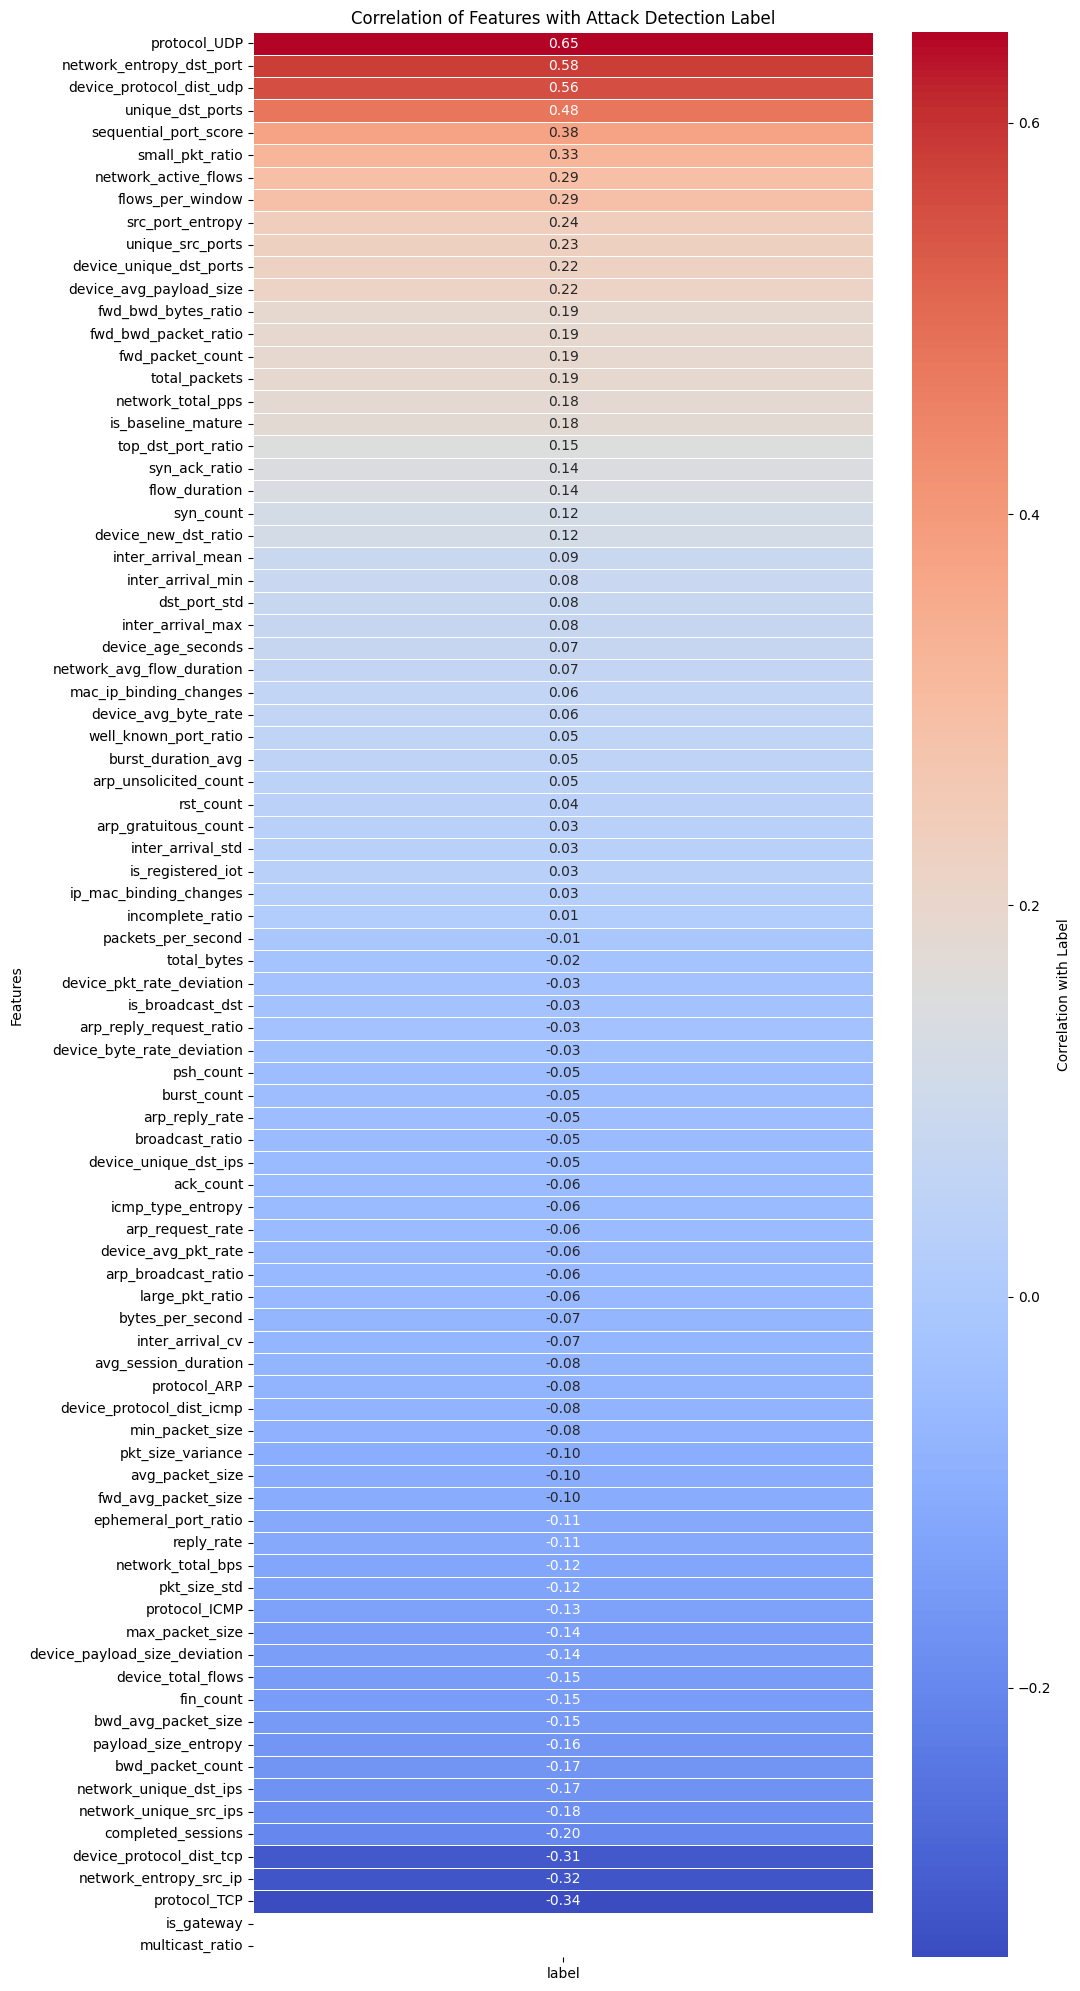

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure plot_df is up-to-date with the latest x_encoded and y
# Assuming x_encoded and y are already preprocessed and aligned by index
plot_df = pd.concat([x_encoded, y.reset_index(drop=True)], axis=1)

# Calculate the correlation of all features with the 'label' column
correlations = plot_df.corr(numeric_only=True)['label'].sort_values(ascending=False)

# Drop the 'label' correlation with itself for cleaner visualization
correlations = correlations.drop('label')

# Plotting the correlations
plt.figure(figsize=(10, 25)) # Adjust figure size to accommodate many features
sns.heatmap(
    correlations.to_frame(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': 'Correlation with Label'}
)
plt.title('Correlation of Features with Attack Detection Label')
plt.ylabel('Features')
plt.show()

##Standrize Data

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the data and transform it
x_standrized = scaler.fit_transform(x_encoded)

# Convert the standardized array back to a DataFrame with original column names
x_standrized = pd.DataFrame(x_standrized, columns=x_encoded.columns)

x_standrized.head()

,flow_duration,total_packets,total_bytes,avg_packet_size,min_packet_size,max_packet_size,packets_per_second,bytes_per_second,syn_count,ack_count,...,arp_request_rate,arp_reply_request_ratio,arp_gratuitous_count,arp_unsolicited_count,mac_ip_binding_changes,ip_mac_binding_changes,protocol_ARP,protocol_ICMP,protocol_TCP,protocol_UDP
0,-0.444753,-0.188456,-0.137235,-0.319755,-0.299019,-0.411303,-0.361025,-0.223480,-0.079164,-0.151949,...,6.483608,-0.127665,-0.026095,-0.047281,-0.060401,-0.060432,3.686056,-0.451794,-1.243201,-0.427916
1,-0.446659,-0.188997,-0.137284,-0.319755,-0.299019,-0.411303,-0.358733,-0.223352,-0.079164,-0.151949,...,10.509274,0.028390,-0.026095,-0.047281,-0.060401,-0.060432,3.686056,-0.451794,-1.243201,-0.427916
2,-0.372350,-0.188727,-0.137162,-0.108635,0.248793,-0.229937,-1.084744,-0.261828,-0.079164,-0.151949,...,-0.171799,-0.127665,-0.026095,-0.047281,-0.060401,-0.060432,-0.271293,2.213397,-1.243201,-0.427916
3,-0.374493,-0.188997,-0.137219,-0.108635,0.248793,-0.229937,-1.093892,-0.263023,-0.079164,-0.151949,...,-0.171799,-0.127665,-0.026095,-0.047281,-0.060401,-0.060432,-0.271293,2.213397,-1.243201,-0.427916
4,-0.443165,-0.188456,-0.137235,-0.319755,-0.299019,-0.411303,-0.573452,-0.235373,-0.079164,-0.151949,...,4.605575,-0.127665,-0.026095,-0.047281,-0.060401,-0.060432,3.686056,-0.451794,-1.243201,-0.427916


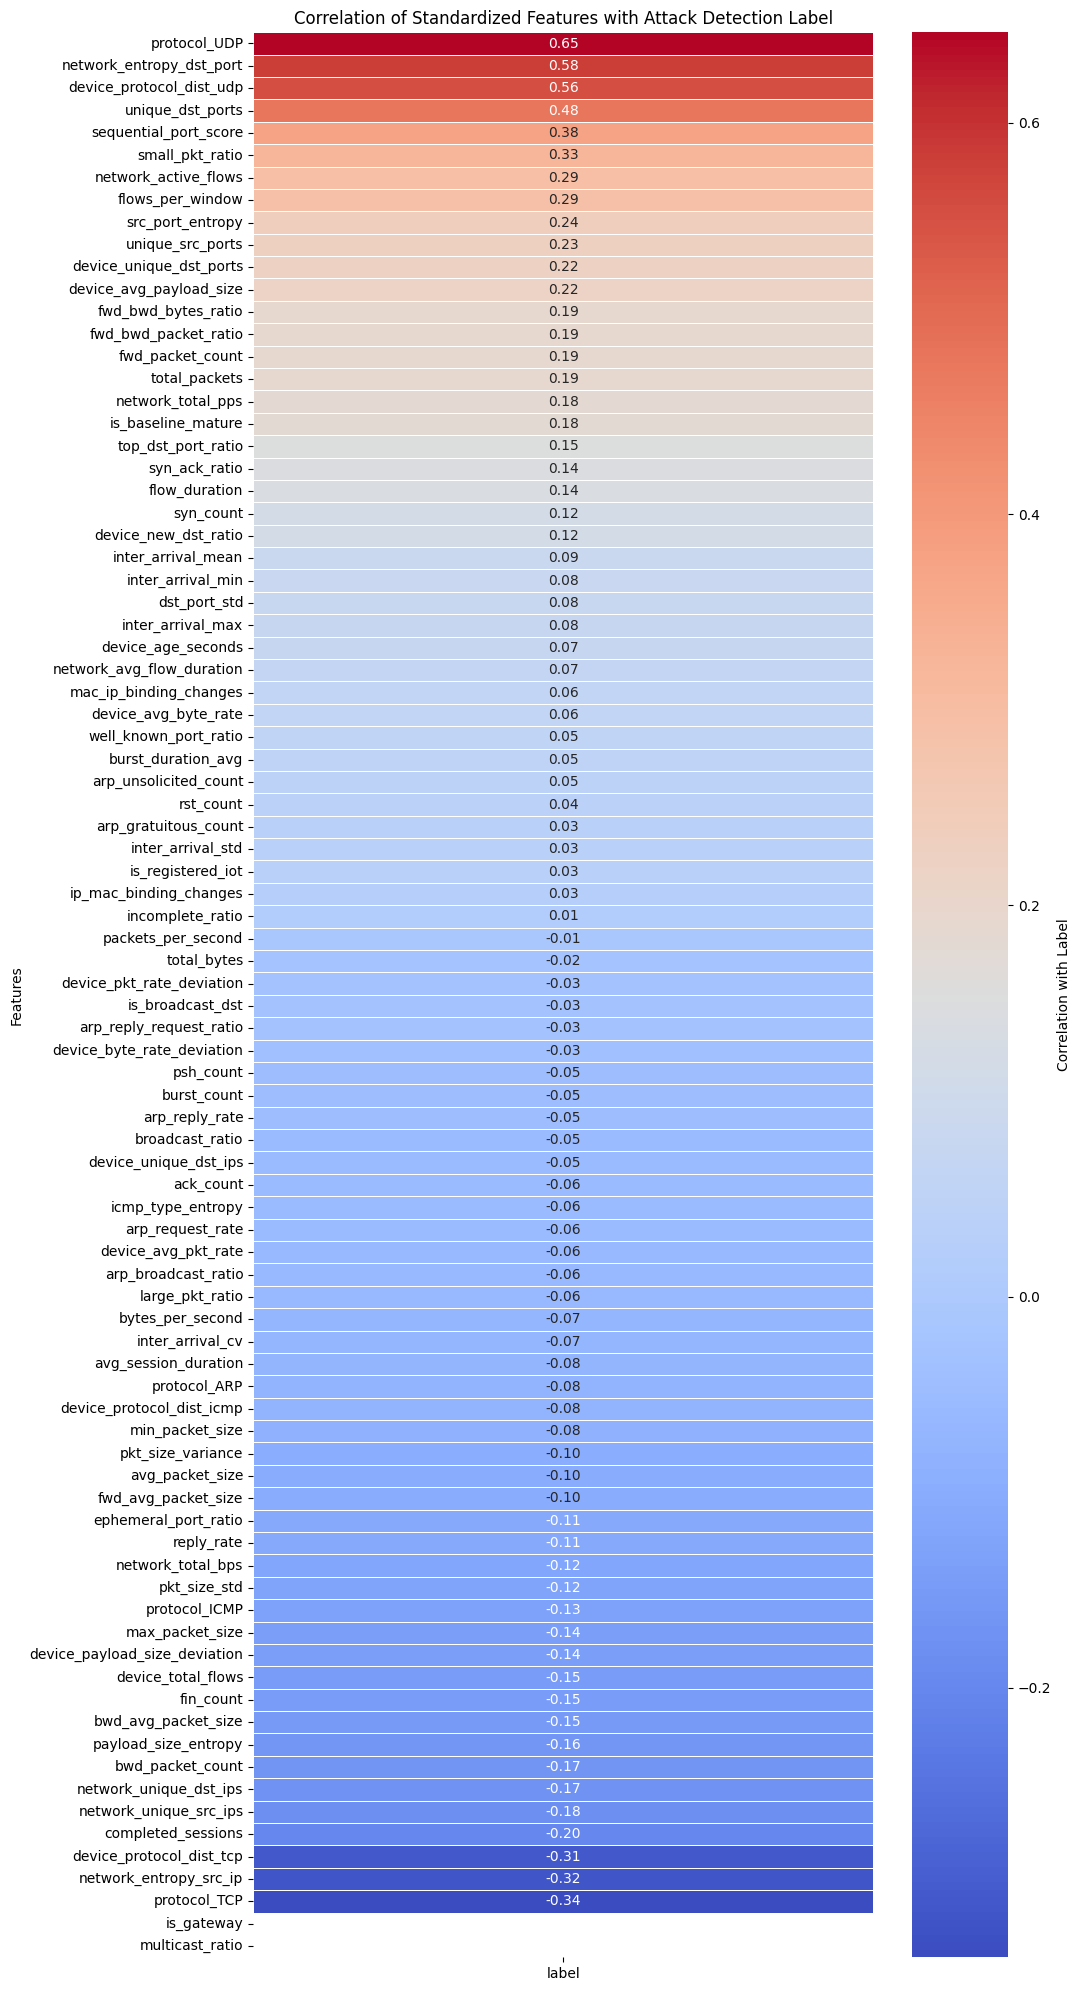

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure plot_df is up-to-date with the latest x_standrized and y
# Assuming x_standrized and y are already preprocessed and aligned by index
plot_df = pd.concat([x_standrized, y.reset_index(drop=True)], axis=1)

# Calculate the correlation of all features with the 'label' column
correlations = plot_df.corr(numeric_only=True)['label'].sort_values(ascending=False)

# Drop the 'label' correlation with itself for cleaner visualization
correlations = correlations.drop('label')

# Plotting the correlations
plt.figure(figsize=(10, 25)) # Adjust figure size to accommodate many features
sns.heatmap(
    correlations.to_frame(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': 'Correlation with Label'}
)
plt.title('Correlation of Standardized Features with Attack Detection Label')
plt.ylabel('Features')
plt.show()

In [ ]:
#Dropping unneeded features
features_to_drop = [
  "incomplete_ratio",
  "packets_per_second",
  "total_bytes",
  "device_pkt_rate_deviation",
  "is_broadcast_dst",
  "arp_reply_request_ratio",
  "device_byte_rate_deviation",
  "arp_gratuitous_count",
  "inter_arrival_std",
  "is_registered_iot",
  "ip_mac_binding_changes",
  "rst_count",
]
x_standrized = x_standrized.drop(columns=features_to_drop, axis=1, errors='ignore')
feature_dict = x_standrized.columns.tolist()
feature_dict

['flow_duration',
 'total_packets',
 'avg_packet_size',
 'min_packet_size',
 'max_packet_size',
 'bytes_per_second',
 'syn_count',
 'ack_count',
 'fin_count',
 'psh_count',
 'unique_src_ports',
 'unique_dst_ports',
 'inter_arrival_mean',
 'inter_arrival_cv',
 'inter_arrival_min',
 'inter_arrival_max',
 'burst_count',
 'burst_duration_avg',
 'fwd_packet_count',
 'bwd_packet_count',
 'fwd_bwd_packet_ratio',
 'fwd_bwd_bytes_ratio',
 'fwd_avg_packet_size',
 'bwd_avg_packet_size',
 'reply_rate',
 'syn_ack_ratio',
 'completed_sessions',
 'avg_session_duration',
 'payload_size_entropy',
 'src_port_entropy',
 'icmp_type_entropy',
 'pkt_size_std',
 'pkt_size_variance',
 'small_pkt_ratio',
 'large_pkt_ratio',
 'top_dst_port_ratio',
 'dst_port_std',
 'well_known_port_ratio',
 'ephemeral_port_ratio',
 'sequential_port_score',
 'flows_per_window',
 'device_total_flows',
 'device_avg_pkt_rate',
 'device_avg_byte_rate',
 'device_unique_dst_ips',
 'device_unique_dst_ports',
 'device_new_dst_ratio',
 '

In [ ]:
features_to_drop = [
  "arp_unsolicited_count",
  "well_known_port_ratio",
  "device_pkt_rate_deviation",
  "burst_duration_avg",
  "broadcast_ratio",
  "arp_reply_rate",
  "burst_count",
  "psh_count",
  "device_unique_dst_ips",
]
x_standrized_v2 = x_standrized.drop(columns=features_to_drop, axis=1, errors='ignore')
feature_dict_v2 = x_standrized_v2.columns.tolist()
feature_dict_v2

['flow_duration',
 'total_packets',
 'avg_packet_size',
 'min_packet_size',
 'max_packet_size',
 'bytes_per_second',
 'syn_count',
 'ack_count',
 'fin_count',
 'unique_src_ports',
 'unique_dst_ports',
 'inter_arrival_mean',
 'inter_arrival_cv',
 'inter_arrival_min',
 'inter_arrival_max',
 'fwd_packet_count',
 'bwd_packet_count',
 'fwd_bwd_packet_ratio',
 'fwd_bwd_bytes_ratio',
 'fwd_avg_packet_size',
 'bwd_avg_packet_size',
 'reply_rate',
 'syn_ack_ratio',
 'completed_sessions',
 'avg_session_duration',
 'payload_size_entropy',
 'src_port_entropy',
 'icmp_type_entropy',
 'pkt_size_std',
 'pkt_size_variance',
 'small_pkt_ratio',
 'large_pkt_ratio',
 'top_dst_port_ratio',
 'dst_port_std',
 'ephemeral_port_ratio',
 'sequential_port_score',
 'flows_per_window',
 'device_total_flows',
 'device_avg_pkt_rate',
 'device_avg_byte_rate',
 'device_unique_dst_ports',
 'device_new_dst_ratio',
 'device_protocol_dist_tcp',
 'device_protocol_dist_udp',
 'device_protocol_dist_icmp',
 'device_avg_payloa

##Data Balancing

In [ ]:
print(y.value_counts())
print()
print(y1.value_counts())

label
0    17189
2     2123
1      220
Name: count, dtype: int64

attack_type
normal                      17189
Control Plane Saturation     1683
Port Scan                     259
ICMP Flood                    153
UDP Flood                      96
SYN Flood                      85
ARP Spoofing                   67
Name: count, dtype: int64


In [ ]:
#Replacing the 1 valeu with 2 in the label (y)
y.replace(2,1,inplace=True)

In [ ]:
print(y.value_counts())
print()
print(y1.value_counts())

label
0    17189
1     2343
Name: count, dtype: int64

attack_type
normal                      17189
Control Plane Saturation     1683
Port Scan                     259
ICMP Flood                    153
UDP Flood                      96
SYN Flood                      85
ARP Spoofing                   67
Name: count, dtype: int64


#Models Training

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import numpy as np

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x_standrized, y1, test_size=0.3, random_state=42)

# Initialize the Random Forest Classifier with specified parameters
rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)

# Train the model
print("Training Random Forest Classifier...")
rf_model.fit(X_train, y_train)
print("Training complete.\n")

# Get unique class names from y1 for target_names
class_names = np.unique(y1).tolist()

# --- Evaluate Training Set Performance ---
print("--- Training Set Evaluation ---")
y_train_pred = rf_model.predict(X_train)

train_report = metrics.classification_report(y_train, y_train_pred, target_names=class_names, output_dict=True)
print(metrics.classification_report(y_train, y_train_pred, target_names=class_names))

train_accuracy = metrics.accuracy_score(y_train, y_train_pred)
print(f"Training Overall Accuracy: {train_accuracy:.4f}")
print(f"Training Macro Avg Precision: {train_report['macro avg']['precision']:.4f}")
print(f"Training Macro Avg Recall: {train_report['macro avg']['recall']:.4f}")
print(f"Training Macro Avg F1-score: {train_report['macro avg']['f1-score']:.4f}\n")


# --- Evaluate Test Set Performance ---
print("--- Test Set Evaluation ---")
# Make predictions on the test set
y_test_pred = rf_model.predict(X_test)

test_report = metrics.classification_report(y_test, y_test_pred, target_names=class_names, output_dict=True)
print(metrics.classification_report(y_test, y_test_pred, target_names=class_names))

# Calculate and print overall accuracy
accuracy = metrics.accuracy_score(y_test, y_test_pred)
print(f"Test Overall Accuracy: {accuracy:.4f}")
print(f"Test Macro Avg Precision: {test_report['macro avg']['precision']:.4f}")
print(f"Test Macro Avg Recall: {test_report['macro avg']['recall']:.4f}")
print(f"Test Macro Avg F1-score: {test_report['macro avg']['f1-score']:.4f}")
print(f"Test Weighted Avg Precision: {test_report['weighted avg']['precision']:.4f}")
print(f"Test Weighted Avg Recall: {test_report['weighted avg']['recall']:.4f}")
print(f"Test Weighted Avg F1-score: {test_report['weighted avg']['f1-score']:.4f}")


Training Random Forest Classifier...
Training complete.

--- Training Set Evaluation ---
                          precision    recall  f1-score   support

            ARP Spoofing       1.00      1.00      1.00        43
Control Plane Saturation       1.00      1.00      1.00      1177
              ICMP Flood       1.00      1.00      1.00       111
               Port Scan       1.00      1.00      1.00       186
               SYN Flood       1.00      1.00      1.00        62
               UDP Flood       1.00      1.00      1.00        64
                  normal       1.00      1.00      1.00     12029

                accuracy                           1.00     13672
               macro avg       1.00      1.00      1.00     13672
            weighted avg       1.00      1.00      1.00     13672

Training Overall Accuracy: 1.0000
Training Macro Avg Precision: 1.0000
Training Macro Avg Recall: 1.0000
Training Macro Avg F1-score: 1.0000

--- Test Set Evaluation ---
            

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import numpy as np

# Define the parameter grid for RandomizedSearchCV
grid = {"max_depth": [None, 5, 10, 20, 30],
        "max_features": ["sqrt", "log2"], # Changed 'auto' to 'sqrt' to resolve InvalidParameterError
        "min_samples_split": [2, 4, 6],
        "min_samples_leaf": [1, 2, 4]}

# Split the data into training and testing sets using x_encoded and y1
X_train_rf_cv, X_test_rf_cv, y_train_rf_cv, y_test_rf_cv = train_test_split(x_encoded, y1, test_size=0.3, random_state=42)

# Initialize the Random Forest Classifier with fixed parameters
# n_estimators=200 and class_weight='balanced' are fixed as requested
# n_jobs=-1 uses all available processors
clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)

# Setup RandomizedSearchCV
# n_iter=100 specifies the number of parameter settings that are sampled
# cv=5 for 5-fold cross-validation
print("Starting RandomizedSearchCV with x_encoded and y1...")
rs_clf = RandomizedSearchCV(estimator=clf,
                            param_distributions=grid,
                            n_iter=100,
                            cv=5,
                            verbose=2,
                            random_state=42,
                            n_jobs=-1)

# Fit the RandomizedSearchCV to the training data
rs_clf.fit(X_train_rf_cv, y_train_rf_cv)
print("RandomizedSearchCV complete.")

# Print the best parameters found
print("\nBest parameters found by RandomizedSearchCV:")
print(rs_clf.best_params_)

# Get the best model
best_rf_model = rs_clf.best_estimator_

# Get unique class names from y1 for target_names
class_names = np.unique(y1).tolist()

# --- Evaluate Best Model on Training Set Performance ---
print("\n--- Best Model Training Set Evaluation ---")
y_train_pred_best = best_rf_model.predict(X_train_rf_cv)

train_report_best = metrics.classification_report(y_train_rf_cv, y_train_pred_best, target_names=class_names, output_dict=True)
print(metrics.classification_report(y_train_rf_cv, y_train_pred_best, target_names=class_names))

train_accuracy_best = metrics.accuracy_score(y_train_rf_cv, y_train_pred_best)
print(f"Training Overall Accuracy: {train_accuracy_best:.4f}")
print(f"Training Macro Avg Precision: {train_report_best['macro avg']['precision']:.4f}")
print(f"Training Macro Avg Recall: {train_report_best['macro avg']['recall']:.4f}")
print(f"Training Macro Avg F1-score: {train_report_best['macro avg']['f1-score']:.4f}\n")

# --- Evaluate Best Model on Test Set Performance ---
print("--- Best Model Test Set Evaluation ---")
# Make predictions on the test set with the best model
y_test_pred_best = best_rf_model.predict(X_test_rf_cv)

test_report_best = metrics.classification_report(y_test_rf_cv, y_test_pred_best, target_names=class_names, output_dict=True)
print(metrics.classification_report(y_test_rf_cv, y_test_pred_best, target_names=class_names))

# Calculate and print overall accuracy
accuracy_best = metrics.accuracy_score(y_test_rf_cv, y_test_pred_best)
print(f"Test Overall Accuracy: {accuracy_best:.4f}")
print(f"Test Macro Avg Precision: {test_report_best['macro avg']['precision']:.4f}")
print(f"Test Macro Avg Recall: {test_report_best['macro avg']['recall']:.4f}")
print(f"Test Macro Avg F1-score: {test_report_best['macro avg']['f1-score']:.4f}")
print(f"Test Weighted Avg Precision: {test_report_best['weighted avg']['precision']:.4f}")
print(f"Test Weighted Avg Recall: {test_report_best['weighted avg']['recall']:.4f}")
print(f"Test Weighted Avg F1-score: {test_report_best['weighted avg']['f1-score']:.4f}")

Starting RandomizedSearchCV with x_encoded and y1...
Fitting 5 folds for each of 90 candidates, totalling 450 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 90 is smaller than n_iter=100. Running 90 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV complete.

Best parameters found by RandomizedSearchCV:
{'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}

--- Best Model Training Set Evaluation ---
                          precision    recall  f1-score   support

            ARP Spoofing       0.98      1.00      0.99        43
Control Plane Saturation       1.00      1.00      1.00      1177
              ICMP Flood       0.97      1.00      0.99       111
               Port Scan       1.00      1.00      1.00       186
               SYN Flood       0.87      1.00      0.93        62
               UDP Flood       0.89      1.00      0.94        64
                  normal       1.00      1.00      1.00     12029

                accuracy                           1.00     13672
               macro avg       0.96      1.00      0.98     13672
            weighted avg       1.00      1.00      1.00     13672

Training Overall Accuracy: 0.9985
Training Macro Avg Precisio

In [ ]:
####Training with (max_depth=15) and (min_samples_leaf=5)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import numpy as np

# Split the data into training and testing sets
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(x_encoded, y1, test_size=0.3, random_state=42)

# Initialize the Random Forest Classifier with specified parameters
rf_model_new = RandomForestClassifier(n_estimators=200,
                                  class_weight='balanced',
                                  random_state=42,
                                  n_jobs=-1,
                                  max_depth=15,
                                  min_samples_leaf=5,
                                  min_samples_split=6,
                                  max_features= 'sqrt')

# Train the model
print("Training Random Forest Classifier with x_encoded and y1...")
rf_model_new.fit(X_train_new, y_train_new)
print("Training complete.\n")

# Get unique class names from y1 for target_names
class_names_new = np.unique(y1).tolist()

# --- Evaluate Training Set Performance ---
print("--- Training Set Evaluation (x_encoded, y1) ---")
y_train_pred_new = rf_model_new.predict(X_train_new)

train_report_new = metrics.classification_report(y_train_new, y_train_pred_new, target_names=class_names_new, output_dict=True)
print(metrics.classification_report(y_train_new, y_train_pred_new, target_names=class_names_new))

train_accuracy_new = metrics.accuracy_score(y_train_new, y_train_pred_new)
print(f"Training Overall Accuracy: {train_accuracy_new:.4f}")
print(f"Training Macro Avg Precision: {train_report_new['macro avg']['precision']:.4f}")
print(f"Training Macro Avg Recall: {train_report_new['macro avg']['recall']:.4f}")
print(f"Training Macro Avg F1-score: {train_report_new['macro avg']['f1-score']:.4f}\n")


# --- Evaluate Test Set Performance ---
print("--- Test Set Evaluation (x_encoded, y1) ---")
# Make predictions on the test set
y_test_pred_new = rf_model_new.predict(X_test_new)

test_report_new = metrics.classification_report(y_test_new, y_test_pred_new, target_names=class_names_new, output_dict=True)
print(metrics.classification_report(y_test_new, y_test_pred_new, target_names=class_names_new))

# Calculate and print overall accuracy
accuracy_new = metrics.accuracy_score(y_test_new, y_test_pred_new)
print(f"Test Overall Accuracy: {accuracy_new:.4f}")
print(f"Test Macro Avg Precision: {test_report_new['macro avg']['precision']:.4f}")
print(f"Test Macro Avg Recall: {test_report_new['macro avg']['recall']:.4f}")
print(f"Test Macro Avg F1-score: {test_report_new['macro avg']['f1-score']:.4f}")
print(f"Test Weighted Avg Precision: {test_report_new['weighted avg']['precision']:.4f}")
print(f"Test Weighted Avg Recall: {test_report_new['weighted avg']['recall']:.4f}")
print(f"Test Weighted Avg F1-score: {test_report_new['weighted avg']['f1-score']:.4f}")

Training Random Forest Classifier with x_encoded and y1...
Training complete.

--- Training Set Evaluation (x_encoded, y1) ---
                          precision    recall  f1-score   support

            ARP Spoofing       0.90      1.00      0.95        43
Control Plane Saturation       1.00      1.00      1.00      1177
              ICMP Flood       0.87      1.00      0.93       111
               Port Scan       1.00      1.00      1.00       186
               SYN Flood       0.84      1.00      0.91        62
               UDP Flood       0.84      1.00      0.91        64
                  normal       1.00      1.00      1.00     12029

                accuracy                           1.00     13672
               macro avg       0.92      1.00      0.96     13672
            weighted avg       1.00      1.00      1.00     13672

Training Overall Accuracy: 0.9966
Training Macro Avg Precision: 0.9204
Training Macro Avg Recall: 0.9995
Training Macro Avg F1-score: 0.9569

--

In [ ]:
####Training with (max_depth=20) and (min_samples_leaf=3)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import numpy as np

# Split the data into training and testing sets
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(x_encoded, y1, test_size=0.3, random_state=42)

# Initialize the Random Forest Classifier with specified parameters
rf_model_v3 = RandomForestClassifier(
                                      n_estimators=300,
                                      class_weight='balanced',
                                      random_state=42,
                                      n_jobs=-1,
                                      max_depth=20,
                                      min_samples_leaf=3,
                                      min_samples_split=5,
                                      max_features='sqrt'
                                    )

# Train the model
print("Training Random Forest Classifier with x_encoded and y1...")
rf_model_new.fit(X_train_new, y_train_new)
print("Training complete.\n")

# Get unique class names from y1 for target_names
class_names_new = np.unique(y1).tolist()

# --- Evaluate Training Set Performance ---
print("--- Training Set Evaluation (x_encoded, y1) ---")
y_train_pred_new = rf_model_new.predict(X_train_new)

train_report_new = metrics.classification_report(y_train_new, y_train_pred_new, target_names=class_names_new, output_dict=True)
print(metrics.classification_report(y_train_new, y_train_pred_new, target_names=class_names_new))

train_accuracy_new = metrics.accuracy_score(y_train_new, y_train_pred_new)
print(f"Training Overall Accuracy: {train_accuracy_new:.4f}")
print(f"Training Macro Avg Precision: {train_report_new['macro avg']['precision']:.4f}")
print(f"Training Macro Avg Recall: {train_report_new['macro avg']['recall']:.4f}")
print(f"Training Macro Avg F1-score: {train_report_new['macro avg']['f1-score']:.4f}\n")


# --- Evaluate Test Set Performance ---
print("--- Test Set Evaluation (x_encoded, y1) ---")
# Make predictions on the test set
y_test_pred_new = rf_model_new.predict(X_test_new)

test_report_new = metrics.classification_report(y_test_new, y_test_pred_new, target_names=class_names_new, output_dict=True)
print(metrics.classification_report(y_test_new, y_test_pred_new, target_names=class_names_new))

# Calculate and print overall accuracy
accuracy_new = metrics.accuracy_score(y_test_new, y_test_pred_new)
print(f"Test Overall Accuracy: {accuracy_new:.4f}")
print(f"Test Macro Avg Precision: {test_report_new['macro avg']['precision']:.4f}")
print(f"Test Macro Avg Recall: {test_report_new['macro avg']['recall']:.4f}")
print(f"Test Macro Avg F1-score: {test_report_new['macro avg']['f1-score']:.4f}")
print(f"Test Weighted Avg Precision: {test_report_new['weighted avg']['precision']:.4f}")
print(f"Test Weighted Avg Recall: {test_report_new['weighted avg']['recall']:.4f}")
print(f"Test Weighted Avg F1-score: {test_report_new['weighted avg']['f1-score']:.4f}")

Training Random Forest Classifier with x_encoded and y1...
Training complete.

--- Training Set Evaluation (x_encoded, y1) ---
                          precision    recall  f1-score   support

            ARP Spoofing       0.90      1.00      0.95        43
Control Plane Saturation       1.00      1.00      1.00      1177
              ICMP Flood       0.87      1.00      0.93       111
               Port Scan       1.00      1.00      1.00       186
               SYN Flood       0.84      1.00      0.91        62
               UDP Flood       0.84      1.00      0.91        64
                  normal       1.00      1.00      1.00     12029

                accuracy                           1.00     13672
               macro avg       0.92      1.00      0.96     13672
            weighted avg       1.00      1.00      1.00     13672

Training Overall Accuracy: 0.9966
Training Macro Avg Precision: 0.9204
Training Macro Avg Recall: 0.9995
Training Macro Avg F1-score: 0.9569

--

In [ ]:
#Smoting and balncing the dataset
from imblearn.over_sampling import SMOTE

sampling_strategy = {
    'ARP Spoofing': 250,
    'SYN Flood': 250,
    'UDP Flood': 250,
    'ICMP Flood': 250,
}

# Convert the one-hot encoded y_train DataFrame back to a single Series of labels
# idxmax(axis=1) finds the column name with the True value for each row
# .str.replace('attack_type_', '') removes the prefix to get the original class names
y_train_labels_for_smote = y_train.idxmax(axis=1).str.replace('attack_type_', '')

smote = SMOTE(sampling_strategy=sampling_strategy,
              random_state=42,
              k_neighbors=4)  # k=4 since ARP Spoofing only has 43 samples
X_res, y_res = smote.fit_resample(X_train, y_train_labels_for_smote)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import numpy as np

rf_final = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    max_depth=None,   # Let trees grow freely on the now-richer data
    min_samples_leaf=2,
    max_features='sqrt'
)

print("Training Random Forest Classifier with SMOTEd data...")
rf_final.fit(X_res, y_res)
print("Training complete.")



# Get unique class names from y_res for target_names
class_names_res = np.unique(y_res).tolist()

# --- Evaluate Training Set Performance (on resampled data) ---
print("--- Training Set Evaluation (SMOTEd data) ---")
y_train_pred_res = rf_final.predict(X_res)

train_report_res = metrics.classification_report(y_res, y_train_pred_res, target_names=class_names_res, output_dict=True)
print(metrics.classification_report(y_res, y_train_pred_res, target_names=class_names_res))

train_accuracy_res = metrics.accuracy_score(y_res, y_train_pred_res)
print(f"Training Overall Accuracy: {train_accuracy_res:.4f}")
print(f"Training Macro Avg Precision: {train_report_res['macro avg']['precision']:.4f}")
print(f"Training Macro Avg Recall: {train_report_res['macro avg']['recall']:.4f}")
print(f"Training Macro Avg F1-score: {train_report_res['macro avg']['f1-score']:.4f}\n")


# Convert the one-hot encoded y_test DataFrame back to a single Series of labels
# idxmax(axis=1) finds the column name with the True value for each row
# .str.replace('attack_type_', '') removes the prefix to get the original class names
y_test_true_labels = y_test.idxmax(axis=1).str.replace('attack_type_', '')

# Use the same class names as for the resampled data, or derive from y_test_true_labels
class_names_test_labels = np.unique(y_test_true_labels).tolist()

# --- Evaluate Test Set Performance (on original test data) ---
print("--- Test Set Evaluation (Original test data) ---")
# Make predictions on the original test set
y_test_pred_final = rf_final.predict(X_test)

test_report_final = metrics.classification_report(y_test_true_labels, y_test_pred_final, target_names=class_names_test_labels, output_dict=True)
print(metrics.classification_report(y_test_true_labels, y_test_pred_final, target_names=class_names_test_labels))

# Calculate and print overall accuracy
accuracy_final = metrics.accuracy_score(y_test_true_labels, y_test_pred_final)
print(f"Test Overall Accuracy: {accuracy_final:.4f}")
print(f"Test Macro Avg Precision: {test_report_final['macro avg']['precision']:.4f}")
print(f"Test Macro Avg Recall: {test_report_final['macro avg']['recall']:.4f}")
print(f"Test Macro Avg F1-score: {test_report_final['macro avg']['f1-score']:.4f}")
print(f"Test Weighted Avg Precision: {test_report_final['weighted avg']['precision']:.4f}")
print(f"Test Weighted Avg Recall: {test_report_final['weighted avg']['recall']:.4f}")
print(f"Test Weighted Avg F1-score: {test_report_final['weighted avg']['f1-score']:.4f}")

Training Random Forest Classifier with SMOTEd data...
Training complete.
--- Training Set Evaluation (SMOTEd data) ---
                          precision    recall  f1-score   support

            ARP Spoofing       0.99      1.00      1.00       250
Control Plane Saturation       1.00      1.00      1.00      1177
              ICMP Flood       0.98      1.00      0.99       250
               Port Scan       1.00      1.00      1.00       186
               SYN Flood       0.97      1.00      0.98       250
               UDP Flood       0.97      1.00      0.98       250
                  normal       1.00      1.00      1.00     12029

                accuracy                           1.00     14392
               macro avg       0.99      1.00      0.99     14392
            weighted avg       1.00      1.00      1.00     14392

Training Overall Accuracy: 0.9985
Training Macro Avg Precision: 0.9878
Training Macro Avg Recall: 0.9997
Training Macro Avg F1-score: 0.9937

--- Test S

In [ ]:
#Smoting and balncing the dataset
from imblearn.over_sampling import SMOTE

sampling_strategy = {
    'ARP Spoofing': 300,
    'SYN Flood': 350,
    'UDP Flood': 300,
    'ICMP Flood': 300,
}

# Convert the one-hot encoded y_train DataFrame back to a single Series of labels
# idxmax(axis=1) finds the column name with the True value for each row
# .str.replace('attack_type_', '') removes the prefix to get the original class names
y_train_labels_for_smote = y_train.idxmax(axis=1).str.replace('attack_type_', '')

smote = SMOTE(sampling_strategy=sampling_strategy,
              random_state=42,
              k_neighbors=4)  # k=4 since ARP Spoofing only has 43 samples
X_res, y_res = smote.fit_resample(X_train, y_train_labels_for_smote)

In [ ]:
####Training with (max_depth=15) and (min_samples_leaf=2) and (spoofing)
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import numpy as np

rf_final = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    max_depth=15,
    min_samples_leaf=2,
    max_features='sqrt'
)

print("Training Random Forest Classifier with SMOTEd data...")
rf_final.fit(X_res, y_res)
print("Training complete.")



# Get unique class names from y_res for target_names
class_names_res = np.unique(y_res).tolist()

# --- Evaluate Training Set Performance (on resampled data) ---
print("--- Training Set Evaluation (SMOTEd data) ---")
y_train_pred_res = rf_final.predict(X_res)

train_report_res = metrics.classification_report(y_res, y_train_pred_res, target_names=class_names_res, output_dict=True)
print(metrics.classification_report(y_res, y_train_pred_res, target_names=class_names_res))

train_accuracy_res = metrics.accuracy_score(y_res, y_train_pred_res)
print(f"Training Overall Accuracy: {train_accuracy_res:.4f}")
print(f"Training Macro Avg Precision: {train_report_res['macro avg']['precision']:.4f}")
print(f"Training Macro Avg Recall: {train_report_res['macro avg']['recall']:.4f}")
print(f"Training Macro Avg F1-score: {train_report_res['macro avg']['f1-score']:.4f}\n")


# Convert the one-hot encoded y_test DataFrame back to a single Series of labels
# idxmax(axis=1) finds the column name with the True value for each row
# .str.replace('attack_type_', '') removes the prefix to get the original class names
y_test_true_labels = y_test.idxmax(axis=1).str.replace('attack_type_', '')

# Use the same class names as for the resampled data, or derive from y_test_true_labels
class_names_test_labels = np.unique(y_test_true_labels).tolist()

# --- Evaluate Test Set Performance (on original test data) ---
print("--- Test Set Evaluation (Original test data) ---")
# Make predictions on the original test set
y_test_pred_final = rf_final.predict(X_test)

test_report_final = metrics.classification_report(y_test_true_labels, y_test_pred_final, target_names=class_names_test_labels, output_dict=True)
print(metrics.classification_report(y_test_true_labels, y_test_pred_final, target_names=class_names_test_labels))

# Calculate and print overall accuracy
accuracy_final = metrics.accuracy_score(y_test_true_labels, y_test_pred_final)
print(f"Test Overall Accuracy: {accuracy_final:.4f}")
print(f"Test Macro Avg Precision: {test_report_final['macro avg']['precision']:.4f}")
print(f"Test Macro Avg Recall: {test_report_final['macro avg']['recall']:.4f}")
print(f"Test Macro Avg F1-score: {test_report_final['macro avg']['f1-score']:.4f}")
print(f"Test Weighted Avg Precision: {test_report_final['weighted avg']['precision']:.4f}")
print(f"Test Weighted Avg Recall: {test_report_final['weighted avg']['recall']:.4f}")
print(f"Test Weighted Avg F1-score: {test_report_final['weighted avg']['f1-score']:.4f}")

Training Random Forest Classifier with SMOTEd data...
Training complete.
--- Training Set Evaluation (SMOTEd data) ---
                          precision    recall  f1-score   support

            ARP Spoofing       0.99      1.00      1.00       300
Control Plane Saturation       1.00      1.00      1.00      1177
              ICMP Flood       0.95      1.00      0.98       300
               Port Scan       1.00      1.00      1.00       186
               SYN Flood       0.98      1.00      0.99       350
               UDP Flood       0.97      1.00      0.99       300
                  normal       1.00      1.00      1.00     12029

                accuracy                           1.00     14642
               macro avg       0.99      1.00      0.99     14642
            weighted avg       1.00      1.00      1.00     14642

Training Overall Accuracy: 0.9977
Training Macro Avg Precision: 0.9853
Training Macro Avg Recall: 0.9996
Training Macro Avg F1-score: 0.9924

--- Test S

In [ ]:
####Training with (max_depth=20) and (min_samples_leaf=2) and (spoofing)
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import numpy as np

rf_final = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    max_depth=20,
    min_samples_leaf=2,
    max_features='sqrt'
)

print("Training Random Forest Classifier with SMOTEd data...")
rf_final.fit(X_res, y_res)
print("Training complete.")



# Get unique class names from y_res for target_names
class_names_res = np.unique(y_res).tolist()

# --- Evaluate Training Set Performance (on resampled data) ---
print("--- Training Set Evaluation (SMOTEd data) ---")
y_train_pred_res = rf_final.predict(X_res)

train_report_res = metrics.classification_report(y_res, y_train_pred_res, target_names=class_names_res, output_dict=True)
print(metrics.classification_report(y_res, y_train_pred_res, target_names=class_names_res))

train_accuracy_res = metrics.accuracy_score(y_res, y_train_pred_res)
print(f"Training Overall Accuracy: {train_accuracy_res:.4f}")
print(f"Training Macro Avg Precision: {train_report_res['macro avg']['precision']:.4f}")
print(f"Training Macro Avg Recall: {train_report_res['macro avg']['recall']:.4f}")
print(f"Training Macro Avg F1-score: {train_report_res['macro avg']['f1-score']:.4f}\n")


# Convert the one-hot encoded y_test DataFrame back to a single Series of labels
# idxmax(axis=1) finds the column name with the True value for each row
# .str.replace('attack_type_', '') removes the prefix to get the original class names
y_test_true_labels = y_test.idxmax(axis=1).str.replace('attack_type_', '')

# Use the same class names as for the resampled data, or derive from y_test_true_labels
class_names_test_labels = np.unique(y_test_true_labels).tolist()

# --- Evaluate Test Set Performance (on original test data) ---
print("--- Test Set Evaluation (Original test data) ---")
# Make predictions on the original test set
y_test_pred_final = rf_final.predict(X_test)

test_report_final = metrics.classification_report(y_test_true_labels, y_test_pred_final, target_names=class_names_test_labels, output_dict=True)
print(metrics.classification_report(y_test_true_labels, y_test_pred_final, target_names=class_names_test_labels))

# Calculate and print overall accuracy
accuracy_final = metrics.accuracy_score(y_test_true_labels, y_test_pred_final)
print(f"Test Overall Accuracy: {accuracy_final:.4f}")
print(f"Test Macro Avg Precision: {test_report_final['macro avg']['precision']:.4f}")
print(f"Test Macro Avg Recall: {test_report_final['macro avg']['recall']:.4f}")
print(f"Test Macro Avg F1-score: {test_report_final['macro avg']['f1-score']:.4f}")
print(f"Test Weighted Avg Precision: {test_report_final['weighted avg']['precision']:.4f}")
print(f"Test Weighted Avg Recall: {test_report_final['weighted avg']['recall']:.4f}")
print(f"Test Weighted Avg F1-score: {test_report_final['weighted avg']['f1-score']:.4f}")

Training Random Forest Classifier with SMOTEd data...
Training complete.
--- Training Set Evaluation (SMOTEd data) ---
                          precision    recall  f1-score   support

            ARP Spoofing       0.99      1.00      1.00       300
Control Plane Saturation       1.00      1.00      1.00      1177
              ICMP Flood       0.99      1.00      0.99       300
               Port Scan       1.00      1.00      1.00       186
               SYN Flood       0.98      1.00      0.99       350
               UDP Flood       0.97      1.00      0.99       300
                  normal       1.00      1.00      1.00     12029

                accuracy                           1.00     14642
               macro avg       0.99      1.00      0.99     14642
            weighted avg       1.00      1.00      1.00     14642

Training Overall Accuracy: 0.9985
Training Macro Avg Precision: 0.9903
Training Macro Avg Recall: 0.9997
Training Macro Avg F1-score: 0.9950

--- Test S

In [ ]:
####Training with (max_depth=25) and (min_samples_leaf=2) and (spoofing)
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import numpy as np

rf_final = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    max_depth=25,
    min_samples_leaf=2,
    max_features='sqrt'
)

print("Training Random Forest Classifier with SMOTEd data...")
rf_final.fit(X_res, y_res)
print("Training complete.")



# Get unique class names from y_res for target_names
class_names_res = np.unique(y_res).tolist()

# --- Evaluate Training Set Performance (on resampled data) ---
print("--- Training Set Evaluation (SMOTEd data) ---")
y_train_pred_res = rf_final.predict(X_res)

train_report_res = metrics.classification_report(y_res, y_train_pred_res, target_names=class_names_res, output_dict=True)
print(metrics.classification_report(y_res, y_train_pred_res, target_names=class_names_res))

train_accuracy_res = metrics.accuracy_score(y_res, y_train_pred_res)
print(f"Training Overall Accuracy: {train_accuracy_res:.4f}")
print(f"Training Macro Avg Precision: {train_report_res['macro avg']['precision']:.4f}")
print(f"Training Macro Avg Recall: {train_report_res['macro avg']['recall']:.4f}")
print(f"Training Macro Avg F1-score: {train_report_res['macro avg']['f1-score']:.4f}\n")


# Convert the one-hot encoded y_test DataFrame back to a single Series of labels
# idxmax(axis=1) finds the column name with the True value for each row
# .str.replace('attack_type_', '') removes the prefix to get the original class names
y_test_true_labels = y_test.idxmax(axis=1).str.replace('attack_type_', '')

# Use the same class names as for the resampled data, or derive from y_test_true_labels
class_names_test_labels = np.unique(y_test_true_labels).tolist()

# --- Evaluate Test Set Performance (on original test data) ---
print("--- Test Set Evaluation (Original test data) ---")
# Make predictions on the original test set
y_test_pred_final = rf_final.predict(X_test)

test_report_final = metrics.classification_report(y_test_true_labels, y_test_pred_final, target_names=class_names_test_labels, output_dict=True)
print(metrics.classification_report(y_test_true_labels, y_test_pred_final, target_names=class_names_test_labels))

# Calculate and print overall accuracy
accuracy_final = metrics.accuracy_score(y_test_true_labels, y_test_pred_final)
print(f"Test Overall Accuracy: {accuracy_final:.4f}")
print(f"Test Macro Avg Precision: {test_report_final['macro avg']['precision']:.4f}")
print(f"Test Macro Avg Recall: {test_report_final['macro avg']['recall']:.4f}")
print(f"Test Macro Avg F1-score: {test_report_final['macro avg']['f1-score']:.4f}")
print(f"Test Weighted Avg Precision: {test_report_final['weighted avg']['precision']:.4f}")
print(f"Test Weighted Avg Recall: {test_report_final['weighted avg']['recall']:.4f}")
print(f"Test Weighted Avg F1-score: {test_report_final['weighted avg']['f1-score']:.4f}")

Training Random Forest Classifier with SMOTEd data...
Training complete.
--- Training Set Evaluation (SMOTEd data) ---
                          precision    recall  f1-score   support

            ARP Spoofing       0.99      1.00      1.00       300
Control Plane Saturation       1.00      1.00      1.00      1177
              ICMP Flood       0.99      1.00      0.99       300
               Port Scan       1.00      1.00      1.00       186
               SYN Flood       0.98      1.00      0.99       350
               UDP Flood       0.97      1.00      0.99       300
                  normal       1.00      1.00      1.00     12029

                accuracy                           1.00     14642
               macro avg       0.99      1.00      0.99     14642
            weighted avg       1.00      1.00      1.00     14642

Training Overall Accuracy: 0.9985
Training Macro Avg Precision: 0.9903
Training Macro Avg Recall: 0.9997
Training Macro Avg F1-score: 0.9950

--- Test S

In [ ]:
####Training with (max_depth=25) and (min_samples_leaf=5) and (spoofing)
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import numpy as np

rf_final = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    max_depth=25,
    min_samples_leaf=5,
    max_features='sqrt'
)

print("Training Random Forest Classifier with SMOTEd data...")
rf_final.fit(X_res, y_res)
print("Training complete.")



# Get unique class names from y_res for target_names
class_names_res = np.unique(y_res).tolist()

# --- Evaluate Training Set Performance (on resampled data) ---
print("--- Training Set Evaluation (SMOTEd data) ---")
y_train_pred_res = rf_final.predict(X_res)

train_report_res = metrics.classification_report(y_res, y_train_pred_res, target_names=class_names_res, output_dict=True)
print(metrics.classification_report(y_res, y_train_pred_res, target_names=class_names_res))

train_accuracy_res = metrics.accuracy_score(y_res, y_train_pred_res)
print(f"Training Overall Accuracy: {train_accuracy_res:.4f}")
print(f"Training Macro Avg Precision: {train_report_res['macro avg']['precision']:.4f}")
print(f"Training Macro Avg Recall: {train_report_res['macro avg']['recall']:.4f}")
print(f"Training Macro Avg F1-score: {train_report_res['macro avg']['f1-score']:.4f}\n")


# Convert the one-hot encoded y_test DataFrame back to a single Series of labels
# idxmax(axis=1) finds the column name with the True value for each row
# .str.replace('attack_type_', '') removes the prefix to get the original class names
y_test_true_labels = y_test.idxmax(axis=1).str.replace('attack_type_', '')

# Use the same class names as for the resampled data, or derive from y_test_true_labels
class_names_test_labels = np.unique(y_test_true_labels).tolist()

# --- Evaluate Test Set Performance (on original test data) ---
print("--- Test Set Evaluation (Original test data) ---")
# Make predictions on the original test set
y_test_pred_final = rf_final.predict(X_test)

test_report_final = metrics.classification_report(y_test_true_labels, y_test_pred_final, target_names=class_names_test_labels, output_dict=True)
print(metrics.classification_report(y_test_true_labels, y_test_pred_final, target_names=class_names_test_labels))

# Calculate and print overall accuracy
accuracy_final = metrics.accuracy_score(y_test_true_labels, y_test_pred_final)
print(f"Test Overall Accuracy: {accuracy_final:.4f}")
print(f"Test Macro Avg Precision: {test_report_final['macro avg']['precision']:.4f}")
print(f"Test Macro Avg Recall: {test_report_final['macro avg']['recall']:.4f}")
print(f"Test Macro Avg F1-score: {test_report_final['macro avg']['f1-score']:.4f}")
print(f"Test Weighted Avg Precision: {test_report_final['weighted avg']['precision']:.4f}")
print(f"Test Weighted Avg Recall: {test_report_final['weighted avg']['recall']:.4f}")
print(f"Test Weighted Avg F1-score: {test_report_final['weighted avg']['f1-score']:.4f}")

Training Random Forest Classifier with SMOTEd data...
Training complete.
--- Training Set Evaluation (SMOTEd data) ---
                          precision    recall  f1-score   support

            ARP Spoofing       0.98      1.00      0.99       300
Control Plane Saturation       1.00      1.00      1.00      1177
              ICMP Flood       0.93      1.00      0.96       300
               Port Scan       1.00      1.00      1.00       186
               SYN Flood       0.96      1.00      0.98       350
               UDP Flood       0.96      1.00      0.98       300
                  normal       1.00      1.00      1.00     12029

                accuracy                           1.00     14642
               macro avg       0.97      1.00      0.99     14642
            weighted avg       1.00      1.00      1.00     14642

Training Overall Accuracy: 0.9960
Training Macro Avg Precision: 0.9748
Training Macro Avg Recall: 0.9993
Training Macro Avg F1-score: 0.9867

--- Test S

In [ ]:
####Training with (max_depth=25) and (min_samples_leaf=10) and (spoofing)
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import numpy as np

rf_final = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    max_depth=25,
    min_samples_leaf=10,
    max_features='sqrt'
)

print("Training Random Forest Classifier with SMOTEd data...")
rf_final.fit(X_res, y_res)
print("Training complete.")



# Get unique class names from y_res for target_names
class_names_res = np.unique(y_res).tolist()

# --- Evaluate Training Set Performance (on resampled data) ---
print("--- Training Set Evaluation (SMOTEd data) ---")
y_train_pred_res = rf_final.predict(X_res)

train_report_res = metrics.classification_report(y_res, y_train_pred_res, target_names=class_names_res, output_dict=True)
print(metrics.classification_report(y_res, y_train_pred_res, target_names=class_names_res))

train_accuracy_res = metrics.accuracy_score(y_res, y_train_pred_res)
print(f"Training Overall Accuracy: {train_accuracy_res:.4f}")
print(f"Training Macro Avg Precision: {train_report_res['macro avg']['precision']:.4f}")
print(f"Training Macro Avg Recall: {train_report_res['macro avg']['recall']:.4f}")
print(f"Training Macro Avg F1-score: {train_report_res['macro avg']['f1-score']:.4f}\n")


# Convert the one-hot encoded y_test DataFrame back to a single Series of labels
# idxmax(axis=1) finds the column name with the True value for each row
# .str.replace('attack_type_', '') removes the prefix to get the original class names
y_test_true_labels = y_test.idxmax(axis=1).str.replace('attack_type_', '')

# Use the same class names as for the resampled data, or derive from y_test_true_labels
class_names_test_labels = np.unique(y_test_true_labels).tolist()

# --- Evaluate Test Set Performance (on original test data) ---
print("--- Test Set Evaluation (Original test data) ---")
# Make predictions on the original test set
y_test_pred_final = rf_final.predict(X_test)

test_report_final = metrics.classification_report(y_test_true_labels, y_test_pred_final, target_names=class_names_test_labels, output_dict=True)
print(metrics.classification_report(y_test_true_labels, y_test_pred_final, target_names=class_names_test_labels))

# Calculate and print overall accuracy
accuracy_final = metrics.accuracy_score(y_test_true_labels, y_test_pred_final)
print(f"Test Overall Accuracy: {accuracy_final:.4f}")
print(f"Test Macro Avg Precision: {test_report_final['macro avg']['precision']:.4f}")
print(f"Test Macro Avg Recall: {test_report_final['macro avg']['recall']:.4f}")
print(f"Test Macro Avg F1-score: {test_report_final['macro avg']['f1-score']:.4f}")
print(f"Test Weighted Avg Precision: {test_report_final['weighted avg']['precision']:.4f}")
print(f"Test Weighted Avg Recall: {test_report_final['weighted avg']['recall']:.4f}")
print(f"Test Weighted Avg F1-score: {test_report_final['weighted avg']['f1-score']:.4f}")

Training Random Forest Classifier with SMOTEd data...
Training complete.
--- Training Set Evaluation (SMOTEd data) ---
                          precision    recall  f1-score   support

            ARP Spoofing       0.96      1.00      0.98       300
Control Plane Saturation       1.00      1.00      1.00      1177
              ICMP Flood       0.80      1.00      0.89       300
               Port Scan       1.00      1.00      1.00       186
               SYN Flood       0.96      1.00      0.98       350
               UDP Flood       0.96      1.00      0.98       300
                  normal       1.00      0.99      1.00     12029

                accuracy                           0.99     14642
               macro avg       0.95      1.00      0.97     14642
            weighted avg       0.99      0.99      0.99     14642

Training Overall Accuracy: 0.9919
Training Macro Avg Precision: 0.9532
Training Macro Avg Recall: 0.9986
Training Macro Avg F1-score: 0.9740

--- Test S

In [ ]:
####Training with (max_depth=25) and (min_samples_leaf=2) using x_standrized_v2
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import numpy as np
from imblearn.over_sampling import SMOTE

# Split the data into training and testing sets using x_standrized_v2 and y1
X_train, X_test, y_train, y_test = train_test_split(x_standrized_v2, y1, test_size=0.3, random_state=42)

# Smoting and balancing the dataset
sampling_strategy = {
    'ARP Spoofing': 300,
    'SYN Flood': 350,
    'UDP Flood': 300,
    'ICMP Flood': 300,
}

smote = SMOTE(sampling_strategy=sampling_strategy,
              random_state=42,
              k_neighbors=4)  # k=4 since ARP Spoofing only has 43 samples
X_res, y_res = smote.fit_resample(X_train, y_train)

rf_final = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    max_depth=25,
    min_samples_leaf=2,
    max_features='sqrt'
)

print("Training Random Forest Classifier with SMOTEd data...")
rf_final.fit(X_res, y_res)
print("Training complete.\n")

# Get unique class names from y_res for target_names
class_names_res = np.unique(y_res).tolist()

# --- Evaluate Training Set Performance (on resampled data) ---
print("--- Training Set Evaluation (SMOTEd data) ---")
y_train_pred_res = rf_final.predict(X_res)

train_report_res = metrics.classification_report(y_res, y_train_pred_res, target_names=class_names_res, output_dict=True)
print(metrics.classification_report(y_res, y_train_pred_res, target_names=class_names_res))

train_accuracy_res = metrics.accuracy_score(y_res, y_train_pred_res)
print(f"Training Overall Accuracy: {train_accuracy_res:.4f}")
print(f"Training Macro Avg Precision: {train_report_res['macro avg']['precision']:.4f}")
print(f"Training Macro Avg Recall: {train_report_res['macro avg']['recall']:.4f}")
print(f"Training Macro Avg F1-score: {train_report_res['macro avg']['f1-score']:.4f}\n")


# Use y_test directly as it's already a Series of labels
class_names_test_labels = np.unique(y_test).tolist()

# --- Evaluate Test Set Performance (on original test data) ---
print("--- Test Set Evaluation (Original test data) ---")
# Make predictions on the original test set
y_test_pred_final = rf_final.predict(X_test)

test_report_final = metrics.classification_report(y_test, y_test_pred_final, target_names=class_names_test_labels, output_dict=True)
print(metrics.classification_report(y_test, y_test_pred_final, target_names=class_names_test_labels))

# Calculate and print overall accuracy
accuracy_final = metrics.accuracy_score(y_test, y_test_pred_final)
print(f"Test Overall Accuracy: {accuracy_final:.4f}")
print(f"Test Macro Avg Precision: {test_report_final['macro avg']['precision']:.4f}")
print(f"Test Macro Avg Recall: {test_report_final['macro avg']['recall']:.4f}")
print(f"Test Macro Avg F1-score: {test_report_final['macro avg']['f1-score']:.4f}")
print(f"Test Weighted Avg Precision: {test_report_final['weighted avg']['precision']:.4f}")
print(f"Test Weighted Avg Recall: {test_report_final['weighted avg']['recall']:.4f}")
print(f"Test Weighted Avg F1-score: {test_report_final['weighted avg']['f1-score']:.4f}")

Training Random Forest Classifier with SMOTEd data...
Training complete.

--- Training Set Evaluation (SMOTEd data) ---
                          precision    recall  f1-score   support

            ARP Spoofing       0.99      1.00      1.00       300
Control Plane Saturation       1.00      1.00      1.00      1177
              ICMP Flood       0.99      1.00      0.99       300
               Port Scan       1.00      1.00      1.00       186
               SYN Flood       0.98      1.00      0.99       350
               UDP Flood       0.97      1.00      0.99       300
                  normal       1.00      1.00      1.00     12029

                accuracy                           1.00     14642
               macro avg       0.99      1.00      0.99     14642
            weighted avg       1.00      1.00      1.00     14642

Training Overall Accuracy: 0.9984
Training Macro Avg Precision: 0.9898
Training Macro Avg Recall: 0.9997
Training Macro Avg F1-score: 0.9947

--- Test 

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import numpy as np

# Re-define the Random Forest Classifier with the specified parameters
# Note: This is creating a new instance for cross-validation within the pipeline
rf_cv_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    max_depth=25,
    min_samples_leaf=2,
    max_features='sqrt'
)

# Define the SMOTE sampling strategy, matching the previous cell's logic
sampling_strategy = {
    'ARP Spoofing': 300,
    'SYN Flood': 350,
    'UDP Flood': 300,
    'ICMP Flood': 300,
}

# Create a pipeline with SMOTE and the Random Forest Classifier
pipeline = Pipeline([
    ('smote', SMOTE(sampling_strategy=sampling_strategy, random_state=42, k_neighbors=4)),
    ('randomforest', rf_cv_model)
])

# Set up Stratified K-Fold cross-validation with 20 splits
# Using the X_train and y_train from the previous split to ensure data integrity
# The split is 70% train, 30% test, so X_train and y_train are the 70% portion
skf = StratifiedKFold(n_splits=20, shuffle=True, random_state=42)

print("Performing 20-fold stratified cross-validation...")

# Perform cross-validation on the training data (before global SMOTE application)
# SMOTE will be applied within each fold's training split by the pipeline
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='accuracy', n_jobs=-1)

print("Cross-validation complete.\n")

print(f"Cross-validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation of CV Accuracy: {np.std(cv_scores):.4f}")

#evaluate macro f1-score
cv_f1_scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='f1_macro', n_jobs=-1)
print(f"Mean CV Macro F1-score: {np.mean(cv_f1_scores):.4f}")

Performing 20-fold stratified cross-validation...
Cross-validation complete.

Cross-validation Accuracy Scores: [0.99561404 0.99561404 0.99561404 0.99561404 0.99122807 0.99561404
 0.99122807 0.99853801 0.99415205 0.99561404 0.99707602 0.99122807
 0.99853587 0.99560761 0.99560761 0.99853587 0.99560761 0.99560761
 0.99560761 0.99414348]
Mean CV Accuracy: 0.9953
Standard Deviation of CV Accuracy: 0.0021
Mean CV Macro F1-score: 0.9349
